# **Instalación de paquetes**

In [ ]:
!pip install statsmodels

In [ ]:
!pip install openpyxl

In [ ]:
!pip install mlxtend

# **Importación de Librerias**

In [4]:
# 1. Se importan las librerias para la realización de las operaciones matemáticas/estadisticas/estructuras de datos
import pandas as pd                                                # Libreria para el manejo de los datos
import numpy as np                                                 # Libreria para operaciones estadísticas/matemáticas/estructuras de datos
import matplotlib.pyplot as plt                                    # Libreria para gráficas 2D
import seaborn as sns                                              # Libreria para gráficas 3D

from statsmodels.tsa.arima.model import ARIMA                                   #Modelo de ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX                          #Modelo de SARIMA
from sklearn.cluster import KMeans, DBSCAN                                      #Libreria para trabajar con algoritmos de clusterización kMeans y DBScan
from sklearn.linear_model import LinearRegression                               #Libreria para trabajar con algoritmos de Regresión Lineal Múltiple
from sklearn.svm import SVR                                                     #Libreria para trabajar con algoritmo de Support Vector Regressor
from sklearn.ensemble import RandomForestRegressor                              #Libreria para trabajar con algoritmo de Random Forest Regressor
import xgboost as xgb                                                           #Libreria para trabajar con algoritmo de XGBoost
import lightgbm as lgbm                                                         #Libreria para trabajar con algoritmo de lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.tree import DecisionTreeRegressor                                  # Libreria para la selección de las mejores características

from statsmodels.tsa.stattools import adfuller                                  #Validación de Estacionalidad para Modelos Estadisticos
from statsmodels.tsa.stattools import kpss                                      #Validación de Estacionalidad para Modelos Estadisticos
from statsmodels.stats.outliers_influence import variance_inflation_factor      #Validación de Colinealidad para Modelos Estadisticos
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf                   #Gráficos acf/pacf para definir visualmente (p,d,q) Modelos Estadisticos
from statsmodels.stats.diagnostic import acorr_ljungbox


from sklearn.metrics import mean_absolute_error, mean_squared_error             # libreria de métricas de evaluación del modelo
from sklearn.metrics import mean_absolute_percentage_error, r2_score            # libreria de métricas de evaluación del modelo

from sklearn.preprocessing import StandardScaler                                # Libraria para la estandarización de las variables
from sklearn.model_selection import train_test_split                            # Libreria para separar la data
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.graphics.gofplots import qqplot
from scipy import stats

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import joblib

import warnings
warnings.filterwarnings("ignore")

# **Definición de funciones**

Función para el cálculo de las métricas de evaluación

In [ ]:
# @title
def compute_regression_metrics(y_test, y_pred, model_name=None, verbose=True):
    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    mask = y_test != 0
    mape = mean_absolute_percentage_error(y_test[mask], y_pred[mask])

    if verbose:
        title = f"Métricas {model_name}" if model_name else "Métricas del modelo"
        print(f"********{title}*********")
        print(f"*")
        print(f"MAE  (Error absoluto medio):            {mae:.2f}")
        print(f"MSE  (Error cuadrático medio):          {mse:.0f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.2f}")
        print(f"MAPE (Error porcentual absoluto medio): {mape:.2%}")
        print(f"R²   (Coeficiente de determinación):    {r2:.2f}")

    return {
        "MAE": mae,
        "MAPE": mape,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

Función para realizar gráficos de validación de las series

In [ ]:
# @title
colors = {
    'train': '#1f77b4',      # azul
    'test': '#ff7f0e',       # naranja
    'pred': '#2ca02c',       # verde
    'ci': '#d62728'          # rojo (intervalos)
}
def regresion_graphs(df_train, df_test, y_pred):
  week_hours=168
  day_hours=24
  fig = plt.figure(figsize=(22, 12))
  gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])

  fig.suptitle('Resultado de la predicción de la demanda de energía eléctrica', fontsize=16)

  ax1 = fig.add_subplot(gs[0, :])
  df_train['demanda_real'].plot(ax=ax1, color=colors['train'], label='Train')
  df_test['demanda_real'].plot(ax=ax1, color=colors['test'], label='Test')
  y_pred.plot(ax=ax1, color=colors['pred'], linestyle='--',linewidth=2.5, label='Predicción')
  ax1.set_ylabel('Demanda del mercado [MWh]')
  ax1.set_title('Periodo total de análisis')
  ax1.legend()
  ax1.grid(True)

  ax2 = fig.add_subplot(gs[1, :])
  df_test['demanda_real'].plot(ax=ax2, color=colors['test'], label='Test')
  y_pred.plot(ax=ax2, color=colors['pred'], linestyle='--',linewidth=2.5, label='Predicción')

  ax2.set_ylabel('Demanda del mercado [MWh]')
  ax2.set_title('Zoom segmento de prueba')
  ax2.legend()
  ax2.grid(True)

  ax3 = fig.add_subplot(gs[2, 0])
  df_test['demanda_real'].iloc[:week_hours].plot( ax=ax3, color=colors['test'], label='Test')
  y_pred.iloc[:week_hours].plot(ax=ax3, color=colors['pred'], linestyle='--', linewidth=2.5, label='Predicción')
  ax3.set_ylabel('Demanda [MWh]')
  ax3.set_title('Zoom semanal (7 días)')
  ax3.legend()
  ax3.grid(True)

  ax4 = fig.add_subplot(gs[2, 1])
  df_test['demanda_real'].iloc[:day_hours].plot(ax=ax4, color=colors['test'], label='Test')
  y_pred.iloc[:day_hours].plot(ax=ax4, color=colors['pred'], linestyle='--', linewidth=2.5, label='Predicción')
  ax4.set_ylabel('Demanda [MWh]')
  ax4.set_title('Zoom diario (24 horas)')
  ax4.legend()
  ax4.grid(True)
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  plt.show()

Función para encontrar los mejores parámetros para ARIMA

In [ ]:
# @title
def auto_arima_params(
    y,
    p_range=range(0, 2),
    d=0,
    q_range=range(0, 2),
    criterion='aic'
):
    results = []

    for p in p_range:
        for q in q_range:
            try:
                model = ARIMA(y, order=(p, d, q))
                fitted = model.fit()

                results.append({
                    'p': p,
                    'd': d,
                    'q': q,
                    'aic': fitted.aic,
                    'bic': fitted.bic
                })

            except Exception:
                continue  # modelos que no convergen

    results_table = pd.DataFrame(results)

    if results_table.empty:
        raise ValueError("Ningún modelo ARIMA pudo ser estimado")

    best_row = results_table.loc[results_table[criterion].idxmin()]
    best_order = (int(best_row.p), d, int(best_row.q))

    best_model = ARIMA(y, order=best_order).fit()

    return best_model, best_order, results_table.sort_values(criterion)

Función para encontrar los mejores parámetros para SARIMA

In [ ]:
# @title
def auto_sarima_params(
    y,
    p_range=range(0, 2),
    q_range=range(0, 2),
    P_range=range(0, 2),
    Q_range=range(0, 2),
    d=1,
    D=1,
    s=24,
    criterion='aic'
):
    results = []

    for p in p_range:
        for q in q_range:
            for P in P_range:
                for Q in Q_range:
                    try:
                        model = SARIMAX(
                            y,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fitted = model.fit(disp=False)

                        results.append({
                            'p': p, 'd': d, 'q': q,
                            'P': P, 'D': D, 'Q': Q, 's': s,
                            'aic': fitted.aic,
                            'bic': fitted.bic
                        })

                    except Exception:
                        continue

    results_table = pd.DataFrame(results)

    if results_table.empty:
        raise ValueError("Ningún modelo SARIMA pudo ser estimado")

    best_row = results_table.loc[results_table[criterion].idxmin()]

    best_order = (
        int(best_row.p),
        d,
        int(best_row.q)
    )

    best_seasonal_order = (
        int(best_row.P),
        D,
        int(best_row.Q),
        s
    )

    best_model = SARIMAX(
        y,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    return best_model, best_order, best_seasonal_order, results_table.sort_values(criterion)

Función de Ingeniería de Variables Temporales para Modelos de Pronóstico de Demanda de Energía

In [ ]:
# @title
def add_time_seasonalities(
    df,
    datetime_index=True,
    add_hour=True,
    add_dayofweek=True,
    add_month=True,
    add_dayofyear=True
):
    """
    Agrega variables de estacionalidad temporal usando codificación seno/coseno.

    Requisitos:
    - df debe tener DatetimeIndex

    Estacionalidades:
    - Hora del día (24)
    - Día de la semana (7)
    - Mes del año (12)
    - Día del año (365.25, robusto para años bisiestos)
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("El DataFrame debe tener un DatetimeIndex")

    df = df.copy()

    # ===============================
    # HORA DEL DÍA (24)
    # ===============================
    if add_hour:
        hour = df.index.hour
        df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    # ===============================
    # DÍA DE LA SEMANA (7)
    # ===============================
    if add_dayofweek:
        dow = df.index.dayofweek  # 0=lunes
        df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
        df['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    # ===============================
    # MES DEL AÑO (12)
    # ===============================
    if add_month:
        month = df.index.month
        df['month_sin'] = np.sin(2 * np.pi * month / 12)
        df['month_cos'] = np.cos(2 * np.pi * month / 12)
    # ===============================
    # DÍA DEL AÑO (365.25) – Bisiestos OK
    # ===============================
    if add_dayofyear:
        doy = df.index.dayofyear
        df['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
        df['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    return df

Función para converir una variable estandarizada en su variable original

In [ ]:
def inverse_scale_y(y_scaled, scaler, index, name='y_pred', as_dataframe=False):
    """
    Invierte el escalado de la variable objetivo.

    Parámetros
    ----------
    y_scaled : array, Series o DataFrame
        Predicciones en escala normalizada.
    scaler : sklearn scaler
        Escalador ajustado previamente con y_train.
    index : pandas Index
        Índice temporal original (ej: y_test.index).
    name : str
        Nombre de la variable de salida.
    as_dataframe : bool
        Si True devuelve DataFrame, si False devuelve Series.

    Retorna
    -------
    Serie o DataFrame con valores en escala original.
    """

    # Convertir a numpy array
    y_array = np.asarray(y_scaled).reshape(-1, 1)

    # Invertir escalado
    y_inversed = scaler.inverse_transform(y_array).flatten()

    # Reconstruir estructura pandas
    if as_dataframe:
        return pd.DataFrame(y_inversed, index=index, columns=[name])
    else:
        return pd.Series(y_inversed, index=index, name=name)

#**Cargue del dataset depurado**

In [5]:
# @title
# ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ColabNotebooks/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# @title
# Se carga la data en un DataFrame
df_dataset=pd.read_excel(root/'df_dataset_demanda_valle_depurado.xlsx')

In [ ]:
# Se imprime el dataframe cargado
df_dataset.head(1)

,fecha,periodo,tipo_dia,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,...,capacidad_solar,capacidad_termica,ano,mes,dia,allsky,clrsky,t2m,rh2m,prectotcorr
0,2020-01-01,1,1--ENE,239.95562,3277.14,122.34,104.24,105.14,29579,494874,...,9913.64,82900,2020,1,1,0.0,0.0,18.027143,99.43,2.272857


#**Análisis con modelos estadísticos**

##**Paso 2: Transformación del dataset para análisis de modelos estadísticos**

In [ ]:
df_new=df_dataset[['fecha','periodo','demanda_real','t2m','precio_bolsa']].copy()

In [ ]:
# Asegurar tipos
df_new['fecha'] = pd.to_datetime(df_new['fecha'])
df_new['periodo'] = df_new['periodo'].astype(int)
# Convertir periodo a hora (periodo - 1)
df_new['hora'] = df_new['periodo'] - 1
# Crear datetime y usar como indice
df_new['datetime'] = df_new['fecha'] + pd.to_timedelta(df_new['hora'], unit='h')
df_new = df_new.set_index('datetime')
# Limpieza opcional
df_new = df_new.drop(columns=['fecha', 'periodo', 'hora'])

In [ ]:
df_new

,demanda_real,t2m,precio_bolsa
datetime,,,
2020-01-01 00:00:00,239.95562,18.027143,72.0169
2020-01-01 01:00:00,230.08609,17.904286,136.7139
2020-01-01 02:00:00,220.81891,17.760000,127.7139
2020-01-01 03:00:00,214.77489,17.628571,127.7139
2020-01-01 04:00:00,209.83059,17.524286,127.7139
...,...,...,...
2025-12-31 19:00:00,342.40726,20.028571,284.4598
2025-12-31 20:00:00,331.80096,19.784286,284.4598
2025-12-31 21:00:00,317.10690,19.577143,284.4598


In [ ]:
df_mod_estadisticos = add_time_seasonalities(df_new,datetime_index=True,add_hour=True,add_dayofweek=True,add_month=True,add_dayofyear=True)

##**Paso 3: Validación de alta correlación y colinealidad entre variables**

In [ ]:
df_mod_estadisticos.head(1)

,demanda_real,t2m,precio_bolsa,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos
datetime,,,,,,,,,,,
2020-01-01,239.95562,18.027143,72.0169,0.0,1.0,0.974928,-0.222521,0.5,0.866025,0.017202,0.999852


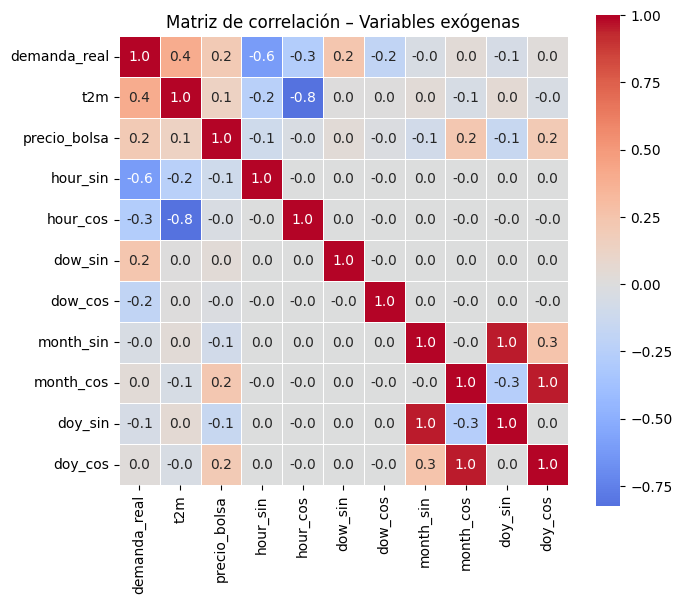

In [ ]:
features = [
    't2m', 'precio_bolsa',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'doy_sin', 'doy_cos'
]

corr = df_mod_estadisticos.corr()

plt.figure(figsize=(7, 7))
sns.heatmap(
    corr,
    annot=True,          # ← muestra los números
    fmt=".1f",           # ← 2 decimales
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de correlación – Variables exógenas')
plt.tight_layout()
plt.show()


La colinealidad preliminar se evaluó mediante una matriz de correlación con anotaciones numéricas, permitiendo identificar relaciones lineales fuertes entre variables exógenas, como en el caso de las variabvles "month_sin" y "month_cos", las cuales presentan alta correlación con "doy_sin" y "doy_cos", por lo cual son eliminadas de las variables exónegas.

In [ ]:
df_mod_estadisticos = df_mod_estadisticos.drop(columns=['month_sin', 'month_cos'])

In [ ]:
df_mod_estadisticos.head(1)

,demanda_real,t2m,precio_bolsa,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos
datetime,,,,,,,,,
2020-01-01,239.95562,18.027143,72.0169,0.0,1.0,0.974928,-0.222521,0.017202,0.999852


In [ ]:
X = df_mod_estadisticos[['t2m','hour_sin','hour_cos']]
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif

,variable,VIF
0,t2m,1.012256
1,hour_sin,1.000962
2,hour_cos,1.011295


| VIF    | Interpretación    |
| ------ | ----------------- |
| 1      | Sin colinealidad  |
| 1 – 5  | Aceptable         |
| 5 – 10 | Problema moderado |
| >10    | Grave             |


In [ ]:
df_mod_estadisticos.index.min(), df_mod_estadisticos.index.max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2025-12-31 23:00:00'))

## **Paso 4: División del segmento de entrenamiento (train) y prueba (test)**

In [ ]:
fecha_corte = '2024-10-18 23:00:00'

df_train = df_mod_estadisticos.loc[:fecha_corte]
df_test  = df_mod_estadisticos.loc[fecha_corte:].iloc[1:]

## **Paso 5: Pruebas de estacionariedad ADF y KPSS**

Estas pruebas permiten determinar si una serie de tiempo es estacionaria, es decir, si sus propiedades estadísticas (media, varianza) se mantienen constantes a lo largo del tiempo.
La estacionariedad es fundamental para aplicar modelos clásicos de pronóstico como ARIMA/SARIMA, ya que estos modelos asumen que la serie no tiene tendencias ni cambios estructurales.
Si la serie no es estacionaria, se deben aplicar transformaciones (como la diferenciación) antes de modelar.
Las pruebas de estacionariedad son el primer paso para validar si podemos aplicar modelos de pronóstico confiables. Si la serie es estacionaria, avanzamos; si no, la transformamos y volvemos a probar.

In [ ]:
# Validación de estacionariedad
result_adf = adfuller(df_train['demanda_real'])
print('ADF Statistic:', result_adf[0])
print('p-value:', result_adf[1])
if result_adf[1] < 0.05:
    print('La serie es estacionaria según ADF.')
else:
    print('La serie NO es estacionaria según ADF.')
print("*****************")
result_kpss = kpss(df_train['demanda_real'], regression='c')
print('KPSS Statistic:', result_kpss[0])
print('p-value:', result_kpss[1])
if result_kpss[1] < 0.05:
    print('La serie NO es estacionaria según KPSS.')
else:
    print('La serie es estacionaria según KPSS.')

ADF Statistic: -19.05549305358107
p-value: 0.0
La serie es estacionaria según ADF.
*****************
KPSS Statistic: 1.9308667712931147
p-value: 0.01
La serie NO es estacionaria según KPSS.


Interpretación de las pruebas de estacionariedad (serie original):

*   Si el p-valor de ADF es menor a 0.05, la serie es estacionaria según ADF.
*   Si el p-valor de KPSS es mayor a 0.05, la serie es estacionaria según KPSS.
*   Si ambas pruebas indican estacionariedad, la serie está lista para modelado ARIMA/SARIMA.
*   Si alguna prueba indica no estacionariedad, se recomienda diferenciar la serie y repetir las pruebas.


In [ ]:
# Diferenciación de la serie y nueva validación de estacionariedad
df_train_diff = df_train['demanda_real'].diff().dropna()
print('Pruebas de estacionariedad sobre la serie diferenciada')
result_adf_diff = adfuller(df_train_diff)
print('ADF Statistic (diferenciada):', result_adf_diff[0])
print('p-value (diferenciada):', result_adf_diff[1])
if result_adf_diff[1] < 0.05:
    print('La serie diferenciada es estacionaria según ADF.')
else:
    print('La serie diferenciada NO es estacionaria según ADF.')

print("*****************")

result_kpss_diff = kpss(df_train_diff, regression='c')
print('KPSS Statistic (diferenciada):', result_kpss_diff[0])
print('p-value (diferenciada):', result_kpss_diff[1])
if result_kpss_diff[1] < 0.05:
    print('La serie diferenciada NO es estacionaria según KPSS.')
else:
    print('La serie diferenciada es estacionaria según KPSS.')

Pruebas de estacionariedad sobre la serie diferenciada
ADF Statistic (diferenciada): -35.82817723689577
p-value (diferenciada): 0.0
La serie diferenciada es estacionaria según ADF.
*****************
KPSS Statistic (diferenciada): 0.0034073716264895423
p-value (diferenciada): 0.1
La serie diferenciada es estacionaria según KPSS.


Interpretación de las pruebas de estacionariedad sobre la serie diferenciada:

*   Si el p-valor de ADF es menor a 0.05, la serie diferenciada es estacionaria según ADF.
*   Si el p-valor de KPSS es mayor a 0.05, la serie diferenciada es estacionaria según KPSS.
*   Si ambas pruebas indican estacionariedad, la serie está lista para modelado ARIMA/SARIMA.
*   Si alguna prueba indica no estacionariedad, puede ser necesario aplicar una segunda diferenciación o revisar la serie por tendenciaas o cambios estructurales.

##**Modelo ARIMA**

### **Paso 6.1: Identificación de parámetros del modelo ARIMA**

| Parámetro | Significado                 |
| --------- | ----------------------------|
| p         | Términos autoregresivos(AR) |
| d         | Diferenciaciones para estacionariedad|
| q         | Términos de media móvil (MA)|


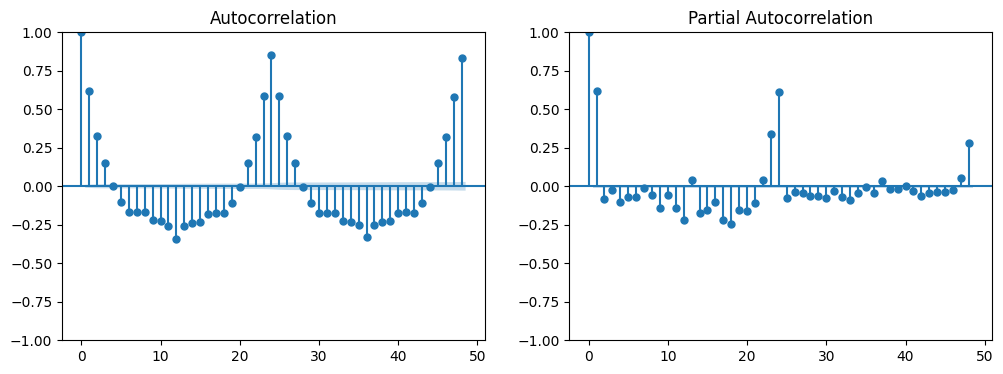

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(df_train_diff, lags=48, ax=axes[0])
plot_pacf(df_train_diff, lags=48, ax=axes[1])
plt.show()

In [ ]:
model_arima, best_order, results_table = auto_arima_params(df_train_diff,p_range=range(0, 2),q_range=range(0, 2))
print(f"Mejor ARIMA encontrado: {best_order}")

Mejor ARIMA encontrado: (1, 0, 1)


###**Paso 7.1: Realizar el entrenamiento del modelo ARIMA**

In [ ]:
model_arima = ARIMA(df_train['demanda_real'], order=(1,0,1))

model_fit = model_arima.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           demanda_real   No. Observations:                42072
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -156349.834
Date:                Thu, 12 Feb 2026   AIC                         312707.669
Time:                        13:50:57   BIC                         312742.257
Sample:                    01-01-2020   HQIC                        312718.591
                         - 10-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        290.5233      1.135    255.939      0.000     288.299     292.748
ar.L1          0.9282      0.002    458.900      0.000       0.924       0.932
ma.L1          0.5620      0.003    176.991      0.0

###**Paso 8.1: Realizar el Pronóstico sobre el conjunto de prueba (test)**

In [ ]:
# @title
y_pred1 = model_fit.forecast(steps=len(df_test))
y_pred1.index = df_test.index
y_pred1 = y_pred1.to_frame(name='predicted_mean')
y_pred1.to_csv(f'{root}/metricas_ARIMA.csv', index=False)

###**Paso 9.1: Cálculo de las métricas de Evaluación**

In [ ]:
metrics = compute_regression_metrics(df_test['demanda_real'], y_pred1, 'ARIMA')

********Métricas ARIMA*********
*
MAE  (Error absoluto medio):            31.83
MSE  (Error cuadrático medio):          1597
RMSE (Raíz del error cuadrático medio): 39.97
MAPE (Error porcentual absoluto medio): 10.77%
R²   (Coeficiente de determinación):    -0.02


###**Paso 10.1: Visualización de la serie (segmentos de entrenamiento y prueba)**

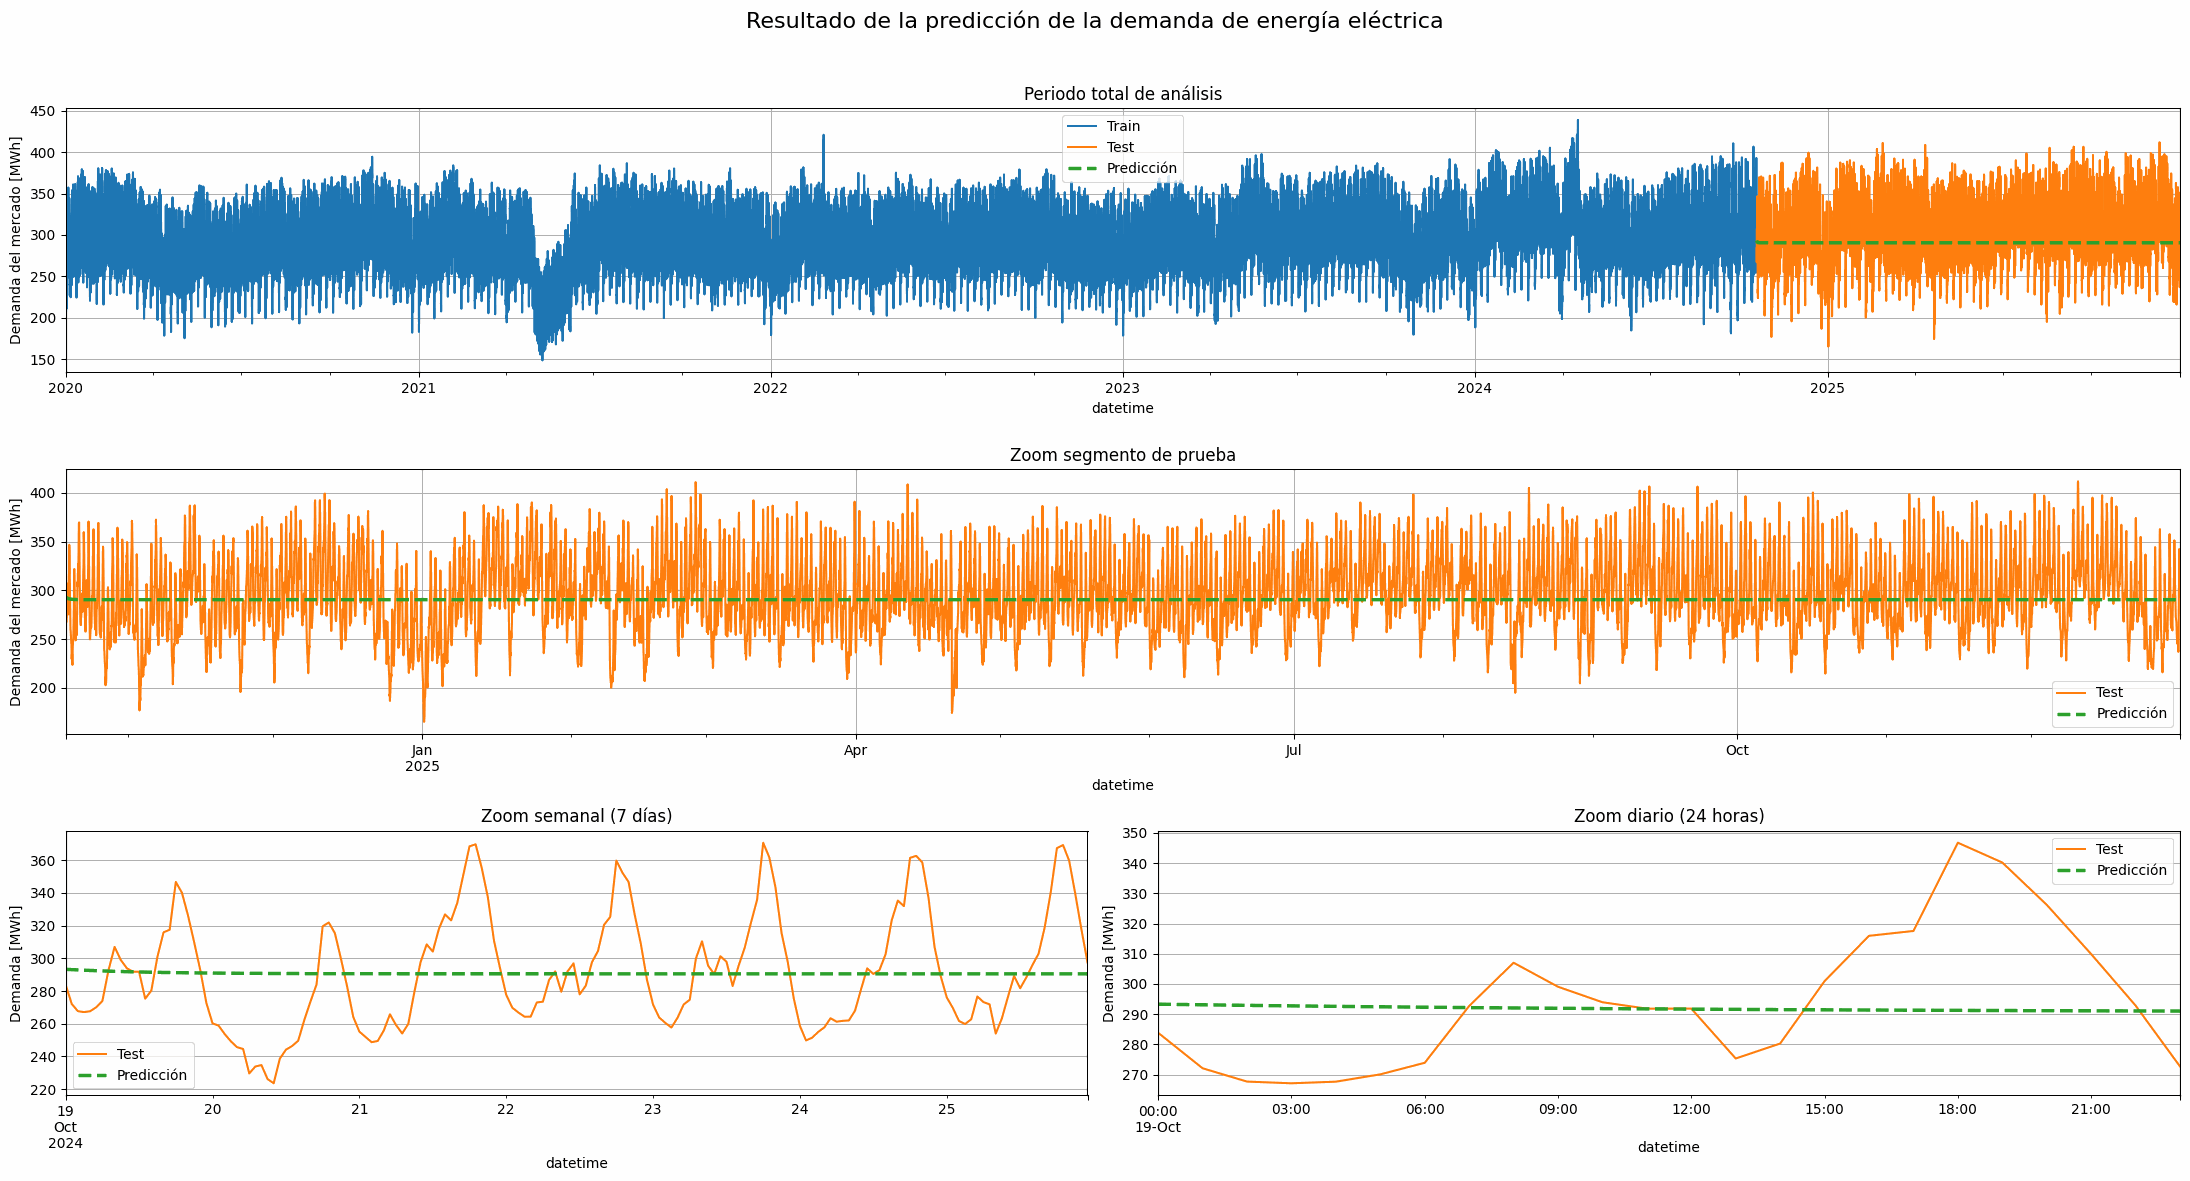

In [ ]:
regresion_graphs(df_train, df_test, y_pred1['predicted_mean'])

##**Modelo SARIMA**

### **Paso 6.2: Identificación de parámetros del modelo SARIMA**

| Parámetro | Significado             |
| --------- | ----------------------- |
| p, d, q   | Dinámica de corto plazo |
| P, D, Q   | Dinámica estacional     |
| s         | Periodicidad estacional |


In [ ]:
model_sarima, order, seasonal_order, results = auto_sarima_params(df_train['demanda_real'],
    p_range=range(1),
    d=0,
    q_range=range(1),
    P_range=range(0, 2),
    Q_range=range(0, 2),
    D=1,
    s=24
)

print("Mejor SARIMA encontrado:")
print("Order:", order)
print("Seasonal order:", seasonal_order)


NameError: name 'auto_sarima_params' is not defined

###**Paso 7.2: Realizar el entrenamiento del modelo SARIMA**

In [ ]:
model_sarima = SARIMAX(df_train['demanda_real'],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(model_sarima.summary())

###**Paso 8.2: Realizar el Pronóstico sobre el conjunto de prueba (test)**

In [ ]:
# @title
forecast = model_fit.get_forecast(steps=len(df_test))
y_pred2 = forecast.predicted_mean
y_pred2.index = df_test.index
y_pred2 = y_pred2.to_frame(name='predicted_mean')
y_pred2.to_csv(f'{root}/metricas_SARIMA.csv', index=False)

###**Paso 9.2: Cálculo de las métricas de Evaluación**

In [ ]:
# @title
mae  = mean_absolute_error(df_test['demanda_real'], y_pred2)
mape = mean_absolute_percentage_error(df_test['demanda_real'], y_pred2)
rmse = np.sqrt(mean_squared_error(df_test['demanda_real'], y_pred2))

print(f"MAE SARIMA : {mae:,.2f}")
print(f"RMSE SARIMA: {rmse:.2f}")
print(f"MAPE SARIMA: {mape:.2%}")

In [ ]:
metrics = compute_regression_metrics(df_test['demanda_real'], y_pred2, 'SARIMA')

###**Paso 10.2: Visualización de la serie (segmentos de entrenamiento y prueba)**

In [ ]:
regresion_graphs(df_train, df_test, y_pred2['predicted_mean'])

##**Modelo ARIMAX**

###**Paso 7.3: Realizar el entrenamiento del modelo ARIMAX**

In [ ]:
model = SARIMAX(
    df_train['demanda_real'],
    exog=df_train[['t2m','precio_bolsa','hour_sin','hour_cos','dow_sin','dow_cos']],
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:           demanda_real   No. Observations:                42072
Model:               SARIMAX(1, 0, 1)   Log Likelihood             -152194.955
Date:                Thu, 12 Feb 2026   AIC                         304407.911
Time:                        13:52:18   BIC                         304485.734
Sample:                    01-01-2020   HQIC                        304432.486
                         - 10-18-2024                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
t2m              3.8089      0.123     30.985      0.000       3.568       4.050
precio_bolsa     0.0240      0.000     48.836      0.000       0.023       0.025
hour_sin       -27.9524      0.411    -67.93

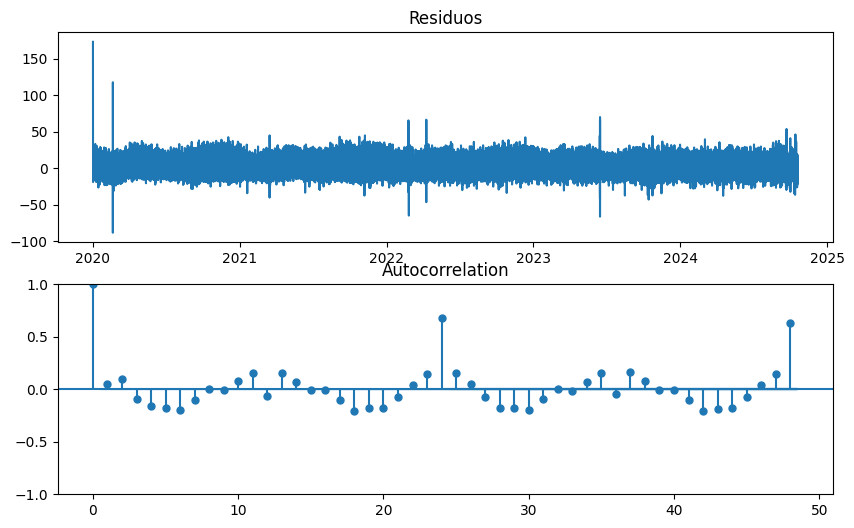

In [ ]:
residuals = results.resid

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(residuals)
ax[0].set_title('Residuos')
plot_acf(residuals.dropna(), lags=48, ax=ax[1])

plt.show()

In [ ]:
ljung_box = acorr_ljungbox(residuals.dropna(), lags=[24], return_df=True)
print(ljung_box)

        lb_stat  lb_pvalue
24  33297.36627        0.0


El modelo explica bien el nivel medio de la demanda, pero no captura completamente la estructura temporal.
Variables exógenas

Todo esto es defendible académicamente:



*   t2m = +3.88: ↑ Temperatura → ↑ Demanda (uso de climatización)
*   precio_bolsa = +0.023: Refleja relación con actividad económica / señales de mercado
(muy común en estudios reales)
*   hour_sin / hour_cos: Coeficientes grandes → patrón horario dominante ✔️

*   dow_sin / dow_cos: Diferencias claras entre días laborales y fines de semana ✔️
*   doy_sin / doy_cos → NO significativos

El modelo ARIMAX inicial presentó coeficientes estadísticamente significativos para las variables exógenas; sin embargo, el análisis de residuos evidenció autocorrelación significativa, asociada principalmente a patrones diarios. En consecuencia, se incorporó un componente estacional al modelo, resultando en una especificación SARIMAX que permitió capturar de forma más adecuada la dinámica temporal de la demanda eléctrica.

###**Paso 8.3: Realizar el Pronóstico sobre el conjunto de prueba (test)**

In [ ]:
# @title
forecast = results.get_forecast(
    steps=len(df_test['demanda_real']),
    exog=df_test[['t2m','precio_bolsa','hour_sin','hour_cos','dow_sin','dow_cos']]
)
y_pred3 = forecast.predicted_mean
y_pred3 = y_pred3.to_frame(name='predicted_mean')
y_pred3.to_csv(f'{root}/metricas_ARIMAX.csv', index=False)

###**Paso 9.3: Cálculo de las métricas de Evaluación**

In [ ]:
metrics = compute_regression_metrics(df_test['demanda_real'], y_pred3, 'ARIMAX')

********Métricas ARIMAX*********
*
MAE  (Error absoluto medio):            203.57
MSE  (Error cuadrático medio):          43771
RMSE (Raíz del error cuadrático medio): 209.22
MAPE (Error porcentual absoluto medio): 68.63%
R²   (Coeficiente de determinación):    -26.99


###**Paso 10.3: Visualización de la serie (segmentos de entrenamiento y prueba)**

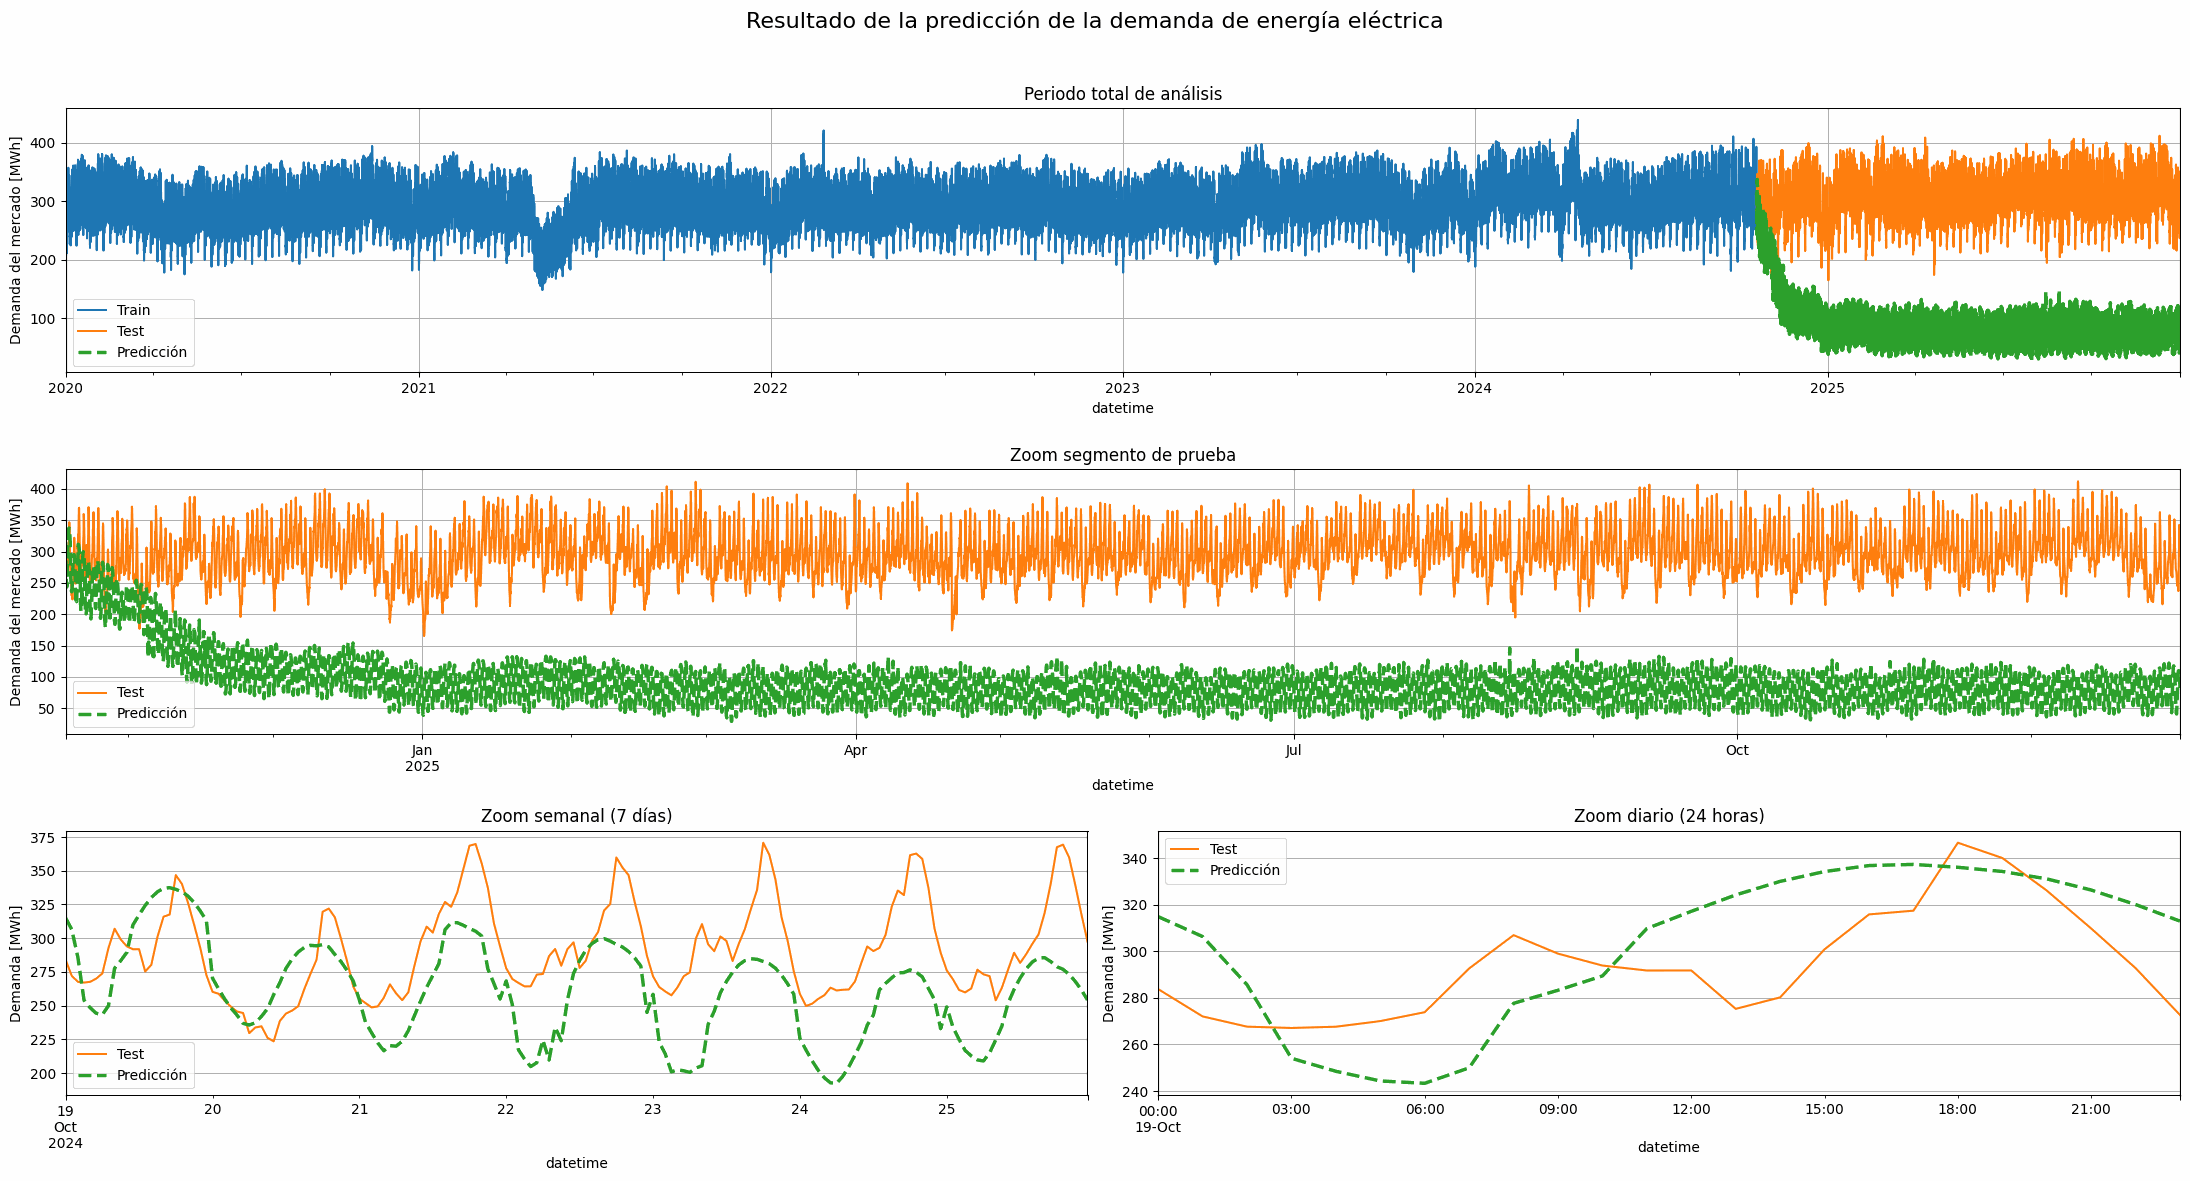

In [ ]:
regresion_graphs(df_train, df_test,y_pred3['predicted_mean'])

##**Modelo SARIMAX**

###**Paso 7.4: Realizar el entrenamiento del modelo SARIMAX**


In [ ]:
# @title
model = SARIMAX(
    df_train['demanda_real'],
    exog=df_train[['t2m','precio_bolsa','hour_sin','hour_cos','dow_sin','dow_cos']],
    order=(1,0,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       demanda_real   No. Observations:                42072
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -132887.176
Date:                            Thu, 12 Feb 2026   AIC                         265796.352
Time:                                    13:59:59   BIC                         265891.464
Sample:                                01-01-2020   HQIC                        265826.387
                                     - 10-18-2024                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
t2m              9.0162      0.106     84.920      0.000       8.808       9.224
precio_bolsa     0.0038      

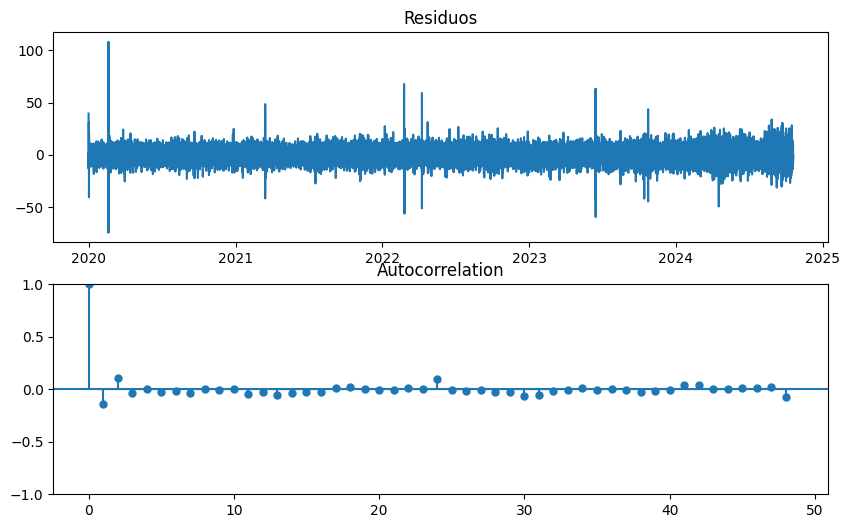

In [ ]:
# @title
residuals = results.resid

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(residuals)
ax[0].set_title('Residuos')
plot_acf(residuals.dropna(), lags=48, ax=ax[1])

plt.show()

In [ ]:
# @title
ljung_box = acorr_ljungbox(residuals.dropna(), lags=[24], return_df=True)
print(ljung_box)

       lb_stat  lb_pvalue
24  2241.69219        0.0


###**Paso 8.4: Realizar el Pronóstico sobre el conjunto de prueba (test)**

In [ ]:
# @title
exog_vars =df_test[['t2m','precio_bolsa','hour_sin','hour_cos','dow_sin','dow_cos']]

In [ ]:
# @title
forecast = results.get_forecast(
    steps=len(df_test['demanda_real']),
    exog=exog_vars
)
y_pred4 = forecast.predicted_mean

In [ ]:
# @title
y_pred4.to_csv(f'{root}/metricas_SARIMAX.csv', index=False)

###**Paso 9.4: Cálculo de las métricas de Evaluación**



In [ ]:
metrics = compute_regression_metrics(df_test['demanda_real'], y_pred4, 'SARIMAX')

********Métricas SARIMAX*********
*
MAE  (Error absoluto medio):            98.64
MSE  (Error cuadrático medio):          11224
RMSE (Raíz del error cuadrático medio): 105.94
MAPE (Error porcentual absoluto medio): 32.83%
R²   (Coeficiente de determinación):    -6.18


###Cálculo de métricas para una semana

In [ ]:
# @title
y_pred4 = y_pred4.to_frame(name='predicted_mean')

In [ ]:
# @title
h = 24 * 7  # 7 días

y_true4_7d = df_test['demanda_real'].iloc[:h]


In [ ]:
# @title
y_pred4_7d = y_pred4.iloc[:h]

In [ ]:
# @title
# y_pred4_7d = y_pred4_7d.to_frame(name='predicted_mean')

In [ ]:
# @title
metrics = compute_regression_metrics(y_true4_7d, y_pred4_7d, 'SARIMAX_7d')

********Métricas SARIMAX_7d*********
*
MAE  (Error absoluto medio):            13.81
MSE  (Error cuadrático medio):          329
RMSE (Raíz del error cuadrático medio): 18.14
MAPE (Error porcentual absoluto medio): 4.72%
R²   (Coeficiente de determinación):    0.72


###**Paso 10.4: Visualización de la serie (segmentos de entrenamiento y prueba)**

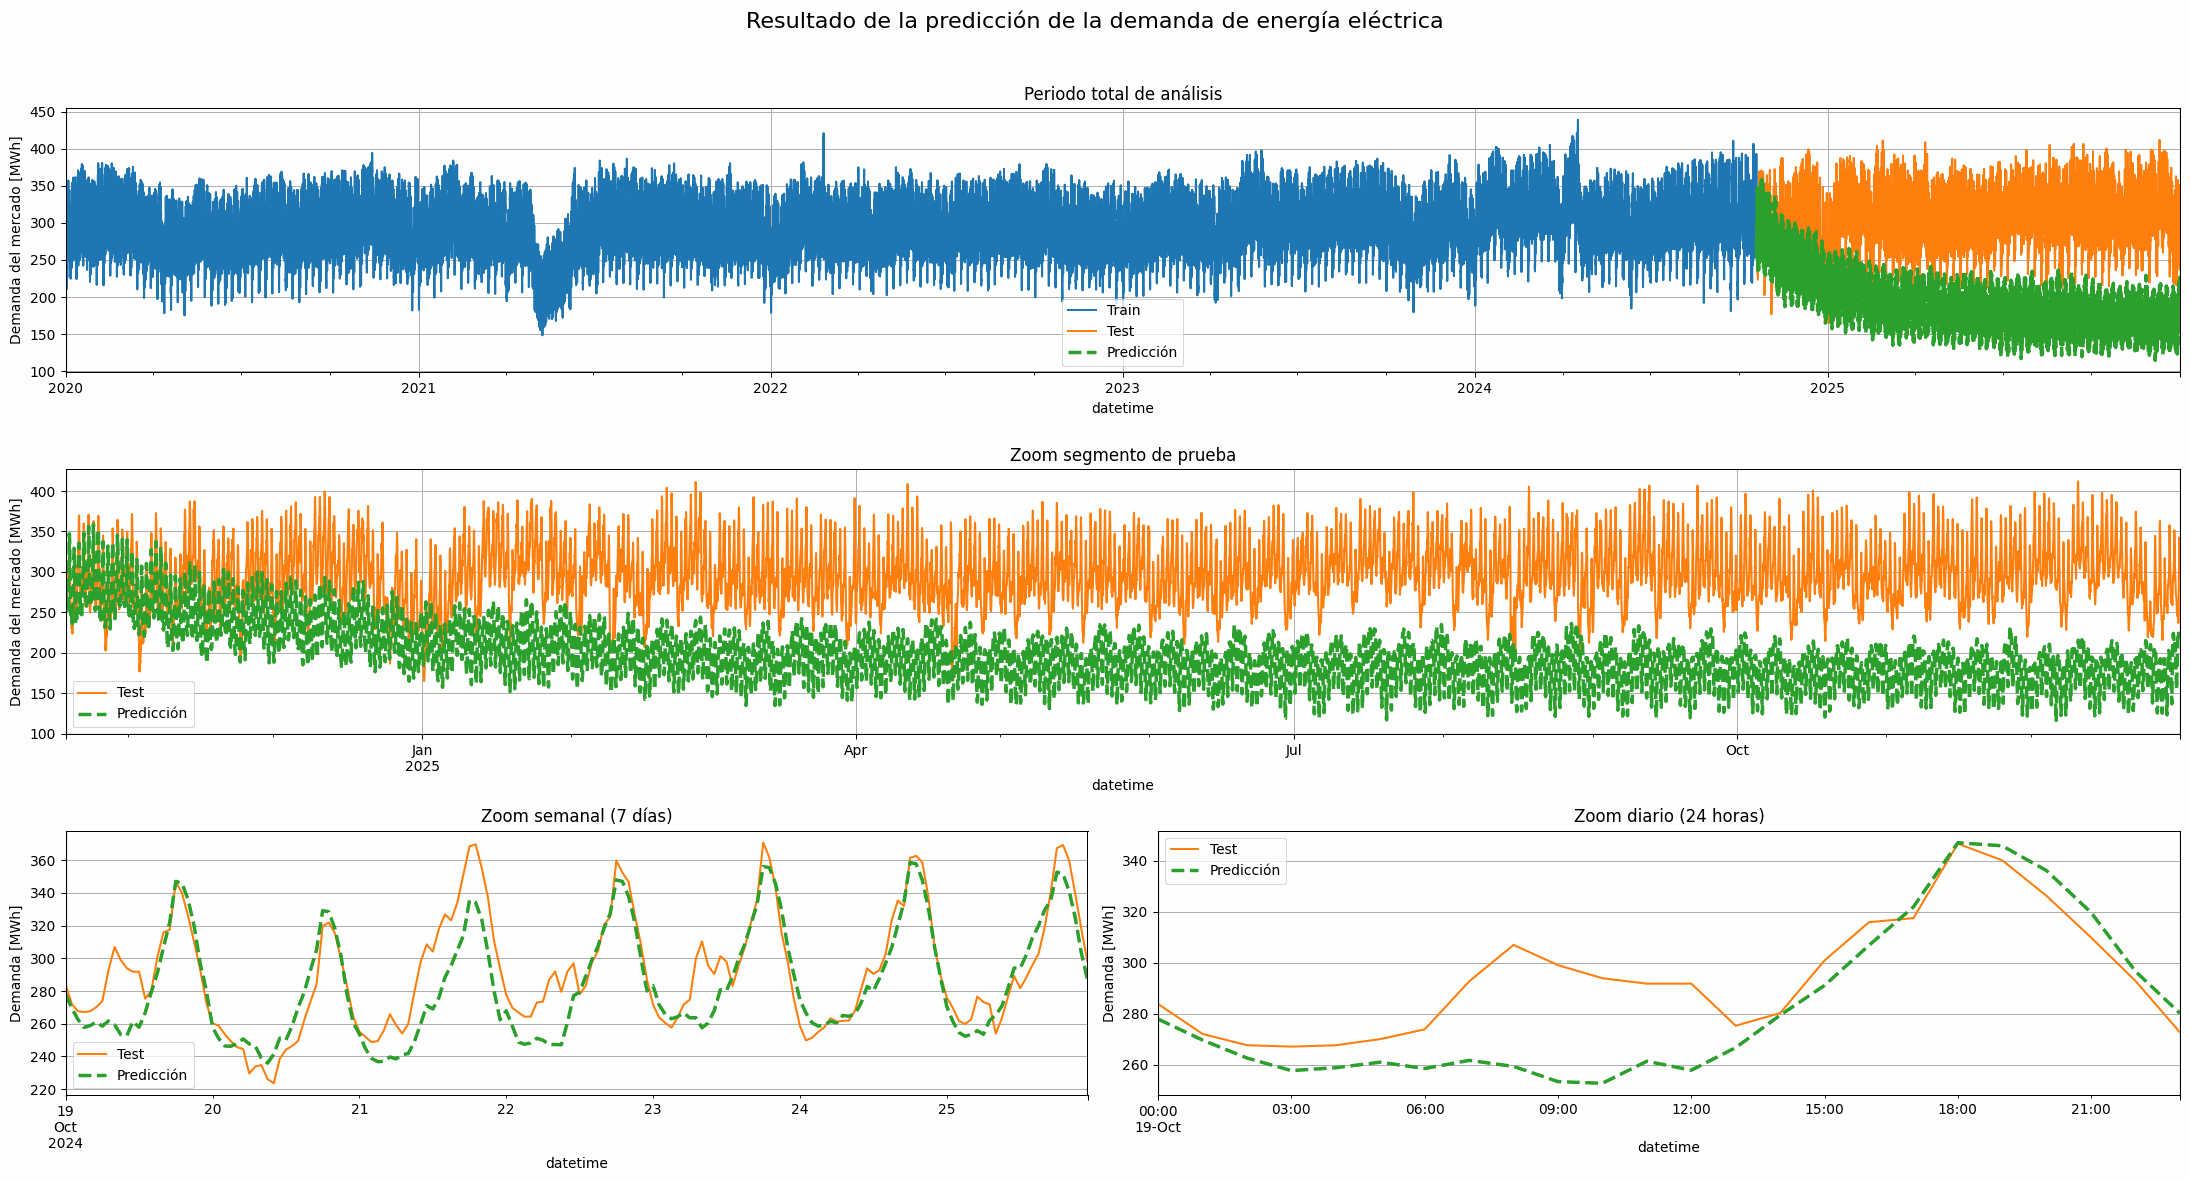

In [ ]:
regresion_graphs(df_train, df_test,y_pred4['predicted_mean'])

La incorporación de un componente estacional diario permitió capturar adecuadamente la dinámica temporal de la demanda eléctrica. Bajo esta especificación, las variables exógenas climáticas, económicas y temporales resultaron estadísticamente significativas, mejorando sustancialmente el ajuste del modelo frente a enfoques ARIMA y ARIMAX no estacionales.

Los modelos ARIMAX y SARIMAX mostraron un mejor desempeño en horizontes de corto plazo (hasta una semana), mientras que su rendimiento se degradó significativamente en pronósticos de largo plazo debido a la dependencia de variables exógenas cuya proyección futura introduce incertidumbre adicional.

Los modelos ARIMA y SARIMA presentan una convergencia del pronóstico hacia el valor medio de la serie, lo que garantiza estabilidad en horizontes largos. En contraste, los modelos ARIMAX y SARIMAX, al incorporar variables exógenas, mejoran el desempeño en horizontes de corto plazo, pero su precisión disminuye progresivamente a medida que aumenta el horizonte de predicción, debido a la incertidumbre asociada a la proyección de dichas variables.

# **Análisis de modelos de Machine Learning**

##**Paso 2: Transformación del dataset para análisis de modelos de Machine Learning**

In [ ]:
df_dataset.shape

(52608, 21)

###Uso de algoritmos de Clusterización para el agrupamiento de "tipo_dia" de forma optima.

In [ ]:
df_new_kmeans=df_dataset.copy()
X =df_new_kmeans[['tipo_dia','demanda_real','periodo']]
features = (
    df_new_kmeans
    .groupby("tipo_dia")["demanda_real"]
    .agg(["mean", "std", "min", "max"])
)

In [ ]:
# df_new_kmeans

In [ ]:
X_profile = (
    df_new_kmeans
    .pivot_table(
        index="tipo_dia",
        columns="periodo",          # Se agregan los periodos del día (1–24)
        values="demanda_real",
        aggfunc="mean"
    )
)

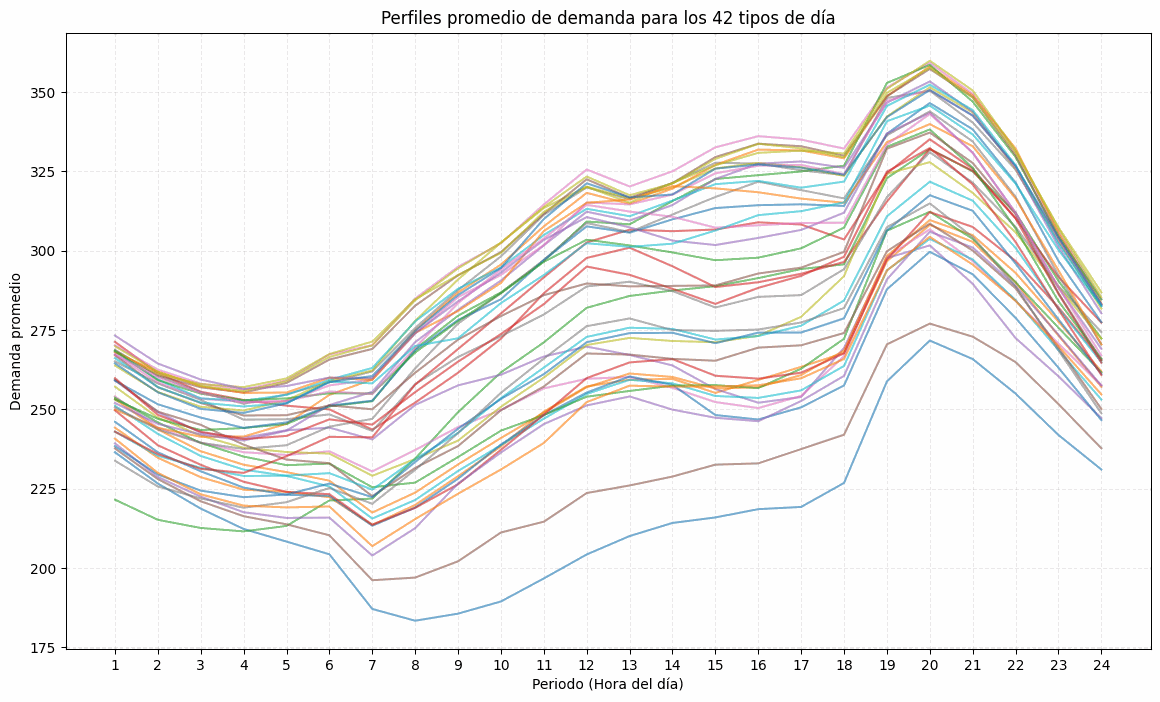

In [ ]:
# ===============================
# 1. Construcción de la tabla pivot
# ===============================
X_profile = (
    df_new_kmeans
    .pivot_table(
        index="tipo_dia",      # 42 tipos de día
        columns="periodo",     # Periodos del día (1–24)
        values="demanda_real",
        aggfunc="mean"
    )
)

# Ordenar columnas (periodos) de menor a mayor
X_profile = X_profile.sort_index(axis=1)

# ===============================
# 2. Gráfico de los 42 perfiles
# ===============================
plt.figure(figsize=(14, 8))

for tipo in X_profile.index:
    plt.plot(
        X_profile.columns,
        X_profile.loc[tipo],
        alpha=0.6
    )

plt.xlabel("Periodo (Hora del día)")
plt.ylabel("Demanda promedio")
plt.title("Perfiles promedio de demanda para los 42 tipos de día")
plt.xticks(range(1, 25))
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [ ]:
# Escalar las variables
# =============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_profile)

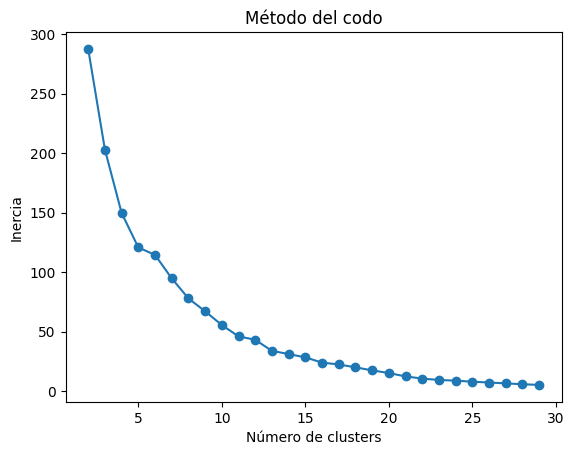

In [ ]:
inertia = []
K = range(2, 30)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

Basado en el gráfico del codo (elbow method)

*   El método del codo indica la reducción significativa de inercia hasta aproximadamente k = 9.
*   Elegir un k menor (por ejemplo 5–6) no permite capturar todos los patrones distintos de demanda horaria.
*   Elegir un k mayor (10–12) solo aporta mínima reducción adicional de inercia, lo que implicaría sobresegmentación y clusters menos interpretables.

Conclusión: k = 9 representa un compromiso óptimo entre compresión de información y complejidad del modelo.

In [ ]:
kmeans = KMeans(n_clusters=9, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

X_profile["cluster"] = clusters

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, X_profile["cluster"])
print(f"Silhouette score (k=9): {score:.3f}")

Silhouette score (k=9): 0.318


Coeficiente de silhouette relativamente bajo es esperado

*   Silhouette = 0.318 indica separación moderada entre clusters, no perfecta.
*   En series temporales y perfiles de demanda eléctrica, los patrones de días laborales, fines de semana y festivos no presentan fronteras duras, sino transiciones suaves.
*   Valores de silhouette entre 0.25 y 0.4 son normales y aceptables en este tipo de datos reales, donde la variabilidad natural es alta.

Conclusión: un silhouette bajo no invalida la elección, sino que refleja la naturaleza continua y solapada de los patrones de demanda.

In [ ]:
# X_profile tiene índice = tipo_dia y columna "cluster"
df_new_kmeans = df_new_kmeans.merge(
    X_profile["cluster"],
    left_on="tipo_dia",
    right_index=True,
    how="left",
    validate="many_to_one"
)

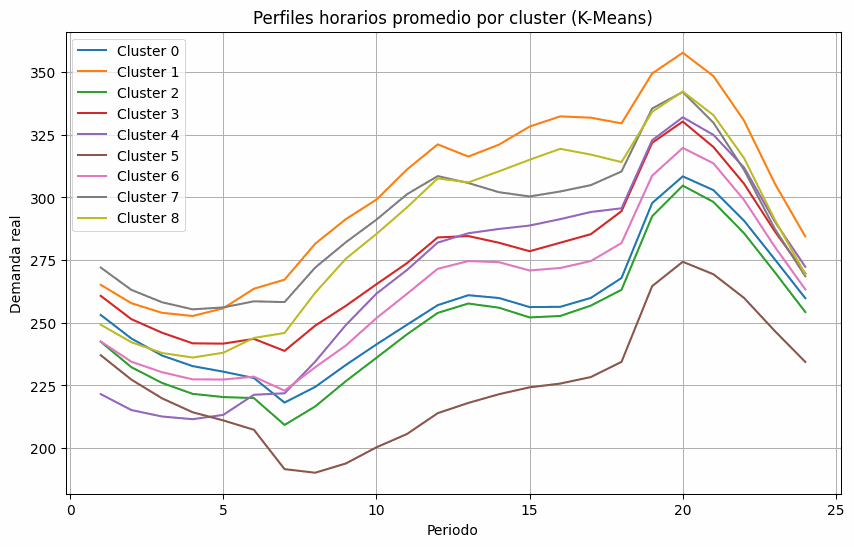

In [ ]:
cluster_mean = (
    df_new_kmeans
    .groupby(["cluster", "periodo"])["demanda_real"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for c in sorted(cluster_mean["cluster"].unique()):
    data_c = cluster_mean[cluster_mean["cluster"] == c]
    plt.plot(
        data_c["periodo"],
        data_c["demanda_real"],
        label=f"Cluster {c}"
    )

plt.xlabel("Periodo")
plt.ylabel("Demanda real")
plt.title("Perfiles horarios promedio por cluster (K-Means)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_new_kmeans = df_new_kmeans.drop(columns=["tipo_dia"])

El número óptimo de clusters se determinó utilizando el método del codo y análisis de perfiles horarios. Se seleccionó k = 9, ya que permite capturar los principales patrones de demanda diaria (laborales, fines de semana, festivos y días especiales) sin sobresegmentación, incluso cuando el coeficiente de silhouette es moderado (0.318), reflejando la continuidad natural de los perfiles de consumo eléctrico.

| Cluster | Tipo de día agrupado |
|--------:|----------------------|
| **0** | DOMINGO, 24--DIC, 31--DIC, DOALF, DOVDIC, JSS |
| **1** | LUNES, MARTES, MIERCOLES, JUEVES, VIERNES, JUVDIC, JUVENE, LUVDIC, MADLF, MAVDIC, MIVDIC, MIVENE, MSS, VIVDIC, VIVENE |
| **2** | 1--MAY, DOALFENE, DSS, VSS |
| **3** | 7--AGO, 8--DIC, SAALFENE |
| **4** | 2--ENE |
| **5** | 1--ENE, 25--DIC |
| **6** | DOVENE, LF, LFENE, SSS |
| **7** | SABADO, 20--JUL, SAALF, SAVDIC, SAVENE |
| **8** | LUVENE, MAVENE |

In [ ]:
# root = Path('/content/drive/MyDrive/ColabNotebooks/ProyectoEspecializacion/data/')

In [ ]:
# # Exportación dataset
# root.mkdir(parents=True, exist_ok=True)

# ruta_salida = root / 'df_dataset_demanda_valle_ajustado.xlsx'
# df_new_kmeans.to_excel(ruta_salida, index=False)

###Transformación de los Cluster del tipo de día en variables binarias

In [ ]:
# @title
# One-Hot Encoding del cluster
cluster_dummies = pd.get_dummies(df_new_kmeans['cluster'], prefix='cluster')

# Concatenar al dataset y eliminar la columna original
df_new_kmeans = pd.concat([df_new_kmeans, cluster_dummies], axis=1)
df_new_kmeans.drop(columns=['cluster'], inplace=True)

In [ ]:
# @title
# Convertir todas las columnas de cluster a enteros 0/1
cluster_cols = [f'cluster_{i}' for i in range(9)]
df_new_kmeans[cluster_cols] = df_new_kmeans[cluster_cols].astype(int)

In [ ]:
# @title
df_new_kmeans_new = df_new_kmeans.copy()

In [ ]:
# @title
# Asegurar tipos
df_new_kmeans_new['fecha'] = pd.to_datetime(df_new_kmeans_new['fecha'])
df_new_kmeans_new['periodo'] = df_new_kmeans_new['periodo'].astype(int)
# Convertir periodo a hora (periodo - 1)
df_new_kmeans_new['hora'] = df_new_kmeans_new['periodo'] - 1
# Crear datetime y usar como indice
df_new_kmeans_new['datetime'] = df_new_kmeans_new['fecha'] + pd.to_timedelta(df_new_kmeans_new['hora'], unit='h')
df_new_kmeans_new = df_new_kmeans_new.set_index('datetime')
# Limpieza opcional
df_new_kmeans_new = df_new_kmeans_new.drop(columns=['fecha', 'periodo', 'hora','ano','mes','dia'])

In [ ]:
df_mod_ml = add_time_seasonalities(df_new_kmeans_new,datetime_index=True,add_hour=True,add_dayofweek=True,add_month=True,add_dayofyear=True)

###Validación de correlación por medio del metodo de Spearman

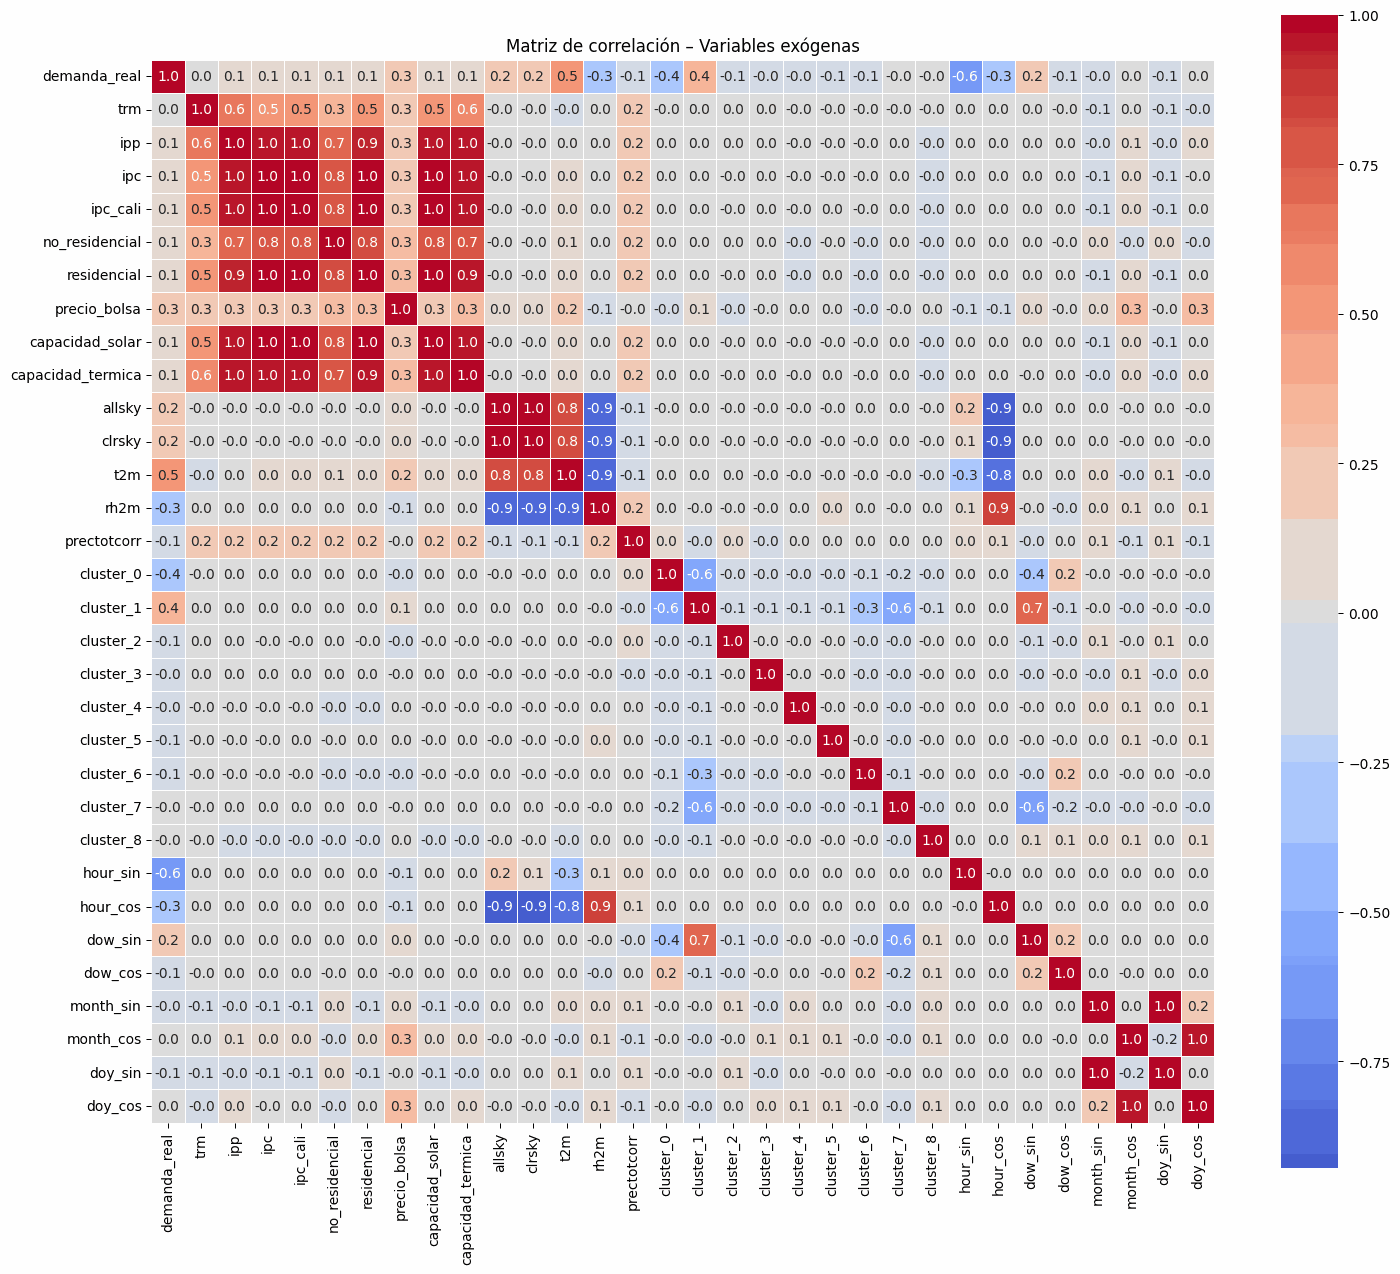

In [ ]:
# @title
corr_spearman = df_mod_ml.corr(method="spearman")

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr_spearman,
    annot=True,          # ← muestra los números
    fmt=".1f",           # ← 2 decimales
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de correlación – Variables exógenas')
plt.tight_layout()
plt.show()

In [ ]:
df_mod_ml_new = df_mod_ml.drop(columns=['ipc_cali', 'month_sin', 'month_cos'])

In [ ]:
df_mod_ml_new

,demanda_real,trm,ipp,ipc,no_residencial,residencial,precio_bolsa,capacidad_solar,capacidad_termica,allsky,...,cluster_5,cluster_6,cluster_7,cluster_8,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,239.95562,3277.14,122.34,104.24,29579,494874,72.0169,9913.64,82900,0.0,...,1,0,0,0,0.000000,1.000000,0.974928,-0.222521,0.017202,0.999852
2020-01-01 01:00:00,230.08609,3277.14,122.34,104.24,29579,494874,136.7139,9913.64,82900,0.0,...,1,0,0,0,0.258819,0.965926,0.974928,-0.222521,0.017202,0.999852
2020-01-01 02:00:00,220.81891,3277.14,122.34,104.24,29579,494874,127.7139,9913.64,82900,0.0,...,1,0,0,0,0.500000,0.866025,0.974928,-0.222521,0.017202,0.999852
2020-01-01 03:00:00,214.77489,3277.14,122.34,104.24,29579,494874,127.7139,9913.64,82900,0.0,...,1,0,0,0,0.707107,0.707107,0.974928,-0.222521,0.017202,0.999852
2020-01-01 04:00:00,209.83059,3277.14,122.34,104.24,29579,494874,127.7139,9913.64,82900,0.0,...,1,0,0,0,0.866025,0.500000,0.974928,-0.222521,0.017202,0.999852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,342.40726,3757.08,181.10,152.27,31574,617447,284.4598,108494.17,102290,0.0,...,0,0,0,0,-0.965926,0.258819,0.974928,-0.222521,-0.004301,0.999991
2025-12-31 20:00:00,331.80096,3757.08,181.10,152.27,31574,617447,284.4598,108494.17,102290,0.0,...,0,0,0,0,-0.866025,0.500000,0.974928,-0.222521,-0.004301,0.999991
2025-12-31 21:00:00,317.10690,3757.08,181.10,152.27,31574,617447,284.4598,108494.17,102290,0.0,...,0,0,0,0,-0.707107,0.707107,0.974928,-0.222521,-0.004301,0.999991


### División del dataset final en los segmento de entrenamiento (train) y prueba (test)

In [ ]:
# Asegurar que el índice es datetime y está ordenado
df_mod_ml_new.index = pd.to_datetime(df_mod_ml_new.index)
df_mod_ml_new = df_mod_ml_new.sort_index()

# Separar variable respuesta y predictores
X = df_mod_ml_new.drop(columns='demanda_real')
y = df_mod_ml_new['demanda_real']

# Punto de corte 80%
split_idx = int(len(df_mod_ml_new) * 0.8)

# División cronológica
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


### Escalamiento de los segmentos de entrenamiento (train) y prueba (test)

La bibliográfia indica que para el entrenamiento de modelos de Machine Learning y Deep Learning que son sensibles a la escala de las variables, como Regresión Lineal (RL), SVR, MLP y GRU, es necesario aplicar un proceso de normalización en las variables continuas mediante StandardScaler. Sin embargo, los modelos basados en árboles como Random Forest y XGBoost no requieren este preprocesamiento. En cuanto a las variables cíclicas codificadas con las funciones seno y coseno, así como las variables binarias producto del análisis de clustering como tipos de día, no son normalizadas.

| Modelo                    | ¿Escalar X?       | ¿Escalar y? | Recomendación      | Motivo               |
| ------------------------- | ----------------- | ----------- | ------------------ | -------------------- |
| **Regresión Lineal (RL)** | ✅ Sí              | 🟡 Opcional | **StandardScaler** | Estabilidad numérica |
| **SVR**                   | ✅ **Obligatorio** | ✅ Sí        | **StandardScaler** | Usa distancias       |
| **Random Forest**         | ❌ No              | ❌ No        | Ninguno            | Árboles              |
| **XGBoost**               | ❌ No              | ❌ No        | Ninguno            | Splits por umbral    |
| **LightGBM**               | ❌ No              | ❌ No        | Ninguno            | Splits por umbral    |
| **MLP**                   | ✅ **Obligatorio** | ✅ Sí        | **StandardScaler** | Gradiente            |
| **RNN Simple**            | ✅ **Obligatorio** | ✅ Sí        | **MinMaxScaler**   | Activaciones tanh    |
| **LSTM**                  | ✅ **Obligatorio** | ✅ Sí        | **MinMaxScaler**   | Puertas sigmoid      |
| **GRU**                   | ✅ **Obligatorio** | ✅ Sí        | **MinMaxScaler**   | Convergencia estable |

Los modelos de Machine Learning sensibles a la escala de las variables, como la Regresión Lineal, SVR y MLP, requieren un proceso de estandarización mediante StandardScaler para garantizar estabilidad numérica y adecuada convergencia. Por su parte, los modelos de Deep Learning basados en redes recurrentes, como GRU, presentan un mejor desempeño cuando las variables son normalizadas a un rango acotado mediante MinMaxScaler. En contraste, los modelos basados en árboles de decisión, como Random Forest y XGBoost, no requieren normalización ni estandarización de las variables de entrada. Por lo cual se decide crear 3 distintos variantes de dataset, como se indica a continuación:


*   dataset_ml_tree → RF, XGBoost (sin escalar)
*   dataset_ml_scaled → RL, SVR, MLP
*   dataset_dl_scaled → GRU (escalado + secuencias)

Esto no es redundancia, es buen diseño experimental.


Uno de los problemas más comunes en el preprocesamiento de datos es la fuga de información (data leakage), la cual ocurre cuando información del conjunto de evaluación es utilizada, directa o indirectamente, durante la etapa de entrenamiento del modelo. Este fenómeno puede presentarse, por ejemplo, cuando los procesos de estandarización o normalización se aplican sobre el conjunto de datos completo antes de realizar la partición en conjuntos de entrenamiento y prueba.

Con el fin de evitar la fuga de información y garantizar una evaluación objetiva del desempeño del modelo, el escalamiento de las variables se realiza únicamente a partir del conjunto de entrenamiento, una vez definida la partición de los datos (80 % entrenamiento y 20 % prueba). Posteriormente, los parámetros obtenidos en el proceso de escalamiento se aplican al conjunto de prueba, asegurando que el modelo no tenga acceso previo a la distribución estadística del segmento de evaluación.

In [ ]:
variables_numericas=['trm', 'ipp', 'ipc', 'no_residencial', 'residencial', 'precio_bolsa',
       'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m',
       'rh2m', 'prectotcorr']

In [ ]:
#Cálculo del escalador "scaler_X" a partir de 'X_train'
scaler_X = StandardScaler()
X_train_scaled_values = scaler_X.fit_transform(X_train[variables_numericas])

#Aplicación del escalador "scaler_X" a 'X_train' para obtener 'X_train_scaled'
X_train_scaled = X_train.copy()
X_train_scaled[variables_numericas] = pd.DataFrame(X_train_scaled_values, columns=variables_numericas, index=X_train.index)

# Se guarda el escalador "scaler_X_lr"
joblib.dump(scaler_X, root / 'scaler_X_rl.pkl')

['/content/drive/MyDrive/ColabNotebooks/ProyectoEspecializacion/data/scaler_X_rl.pkl']

In [ ]:
X_test_scaled = X_test.copy()

#Aplicación del escalador 'scaler_X' a 'X_test' para obtener 'X_test_scaled'
X_test_scaled[variables_numericas] = pd.DataFrame(scaler_X.transform(X_test[variables_numericas]), columns=variables_numericas, index=X_test.index)

In [ ]:
y_train = y_train.squeeze()
#Cálculo del escalador "scaler_y" a partir de 'y_train'
scaler_y = StandardScaler()

#Aplicación del escalador "scaler_y" a 'y_train' para obtener 'y_train_scaled'
y_train_scaled_values = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_train_scaled = pd.Series(y_train_scaled_values.flatten(),index=y_train.index,name=y_train.name)

# Se guarda el escalador "scaler_y"
joblib.dump(scaler_y, root / 'scaler_y.pkl')

['/content/drive/MyDrive/ColabNotebooks/ProyectoEspecializacion/data/scaler_y.pkl']

In [ ]:
y_test = y_test.squeeze()
#Aplicación del escalador 'scaler_y' a 'y_test' para obtener 'y_test_scaled'
y_test_scaled = pd.Series(scaler_y.transform(y_test.values.reshape(-1, 1)).flatten(),index=y_test.index,name=y_test.name)

El escalamiento de las variables se realiza ajustando los parámetros de normalización exclusivamente con el conjunto de entrenamiento, con el fin de evitar fuga de información. Posteriormente, dichos parámetros se aplican al conjunto de prueba, garantizando que el modelo no tenga acceso indirecto a la distribución estadística de los datos de evaluación.

## **Model Linear Regression sin escalamiento**

In [ ]:
lr = LinearRegression()

###Forward selection

In [ ]:
# Forward selection
sfs_forward = SFS(lr,
                  k_features='best',
                  forward=True,
                  floating=False,
                  scoring='r2',
                  cv=5,
                  n_jobs=-1)

sfs_forward = sfs_forward.fit(X_train, y_train)

# Acceder al historial
history_forward = sfs_forward.get_metric_dict()

print("\n Forward selection paso a paso:")
for step, info in history_forward.items():
    variables = list(info['feature_names'])
    r2 = info['avg_score']
    print(f"Paso {step}: Variables seleccionadas: {variables}, R² promedio en CV: {r2:.4f}")


 Forward selection paso a paso:
Paso 1: Variables seleccionadas: ['hour_sin'], R² promedio en CV: 0.3594
Paso 2: Variables seleccionadas: ['cluster_1', 'hour_sin'], R² promedio en CV: 0.4904
Paso 3: Variables seleccionadas: ['cluster_1', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.5974
Paso 4: Variables seleccionadas: ['cluster_1', 'cluster_7', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6534
Paso 5: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_7', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6740
Paso 6: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_5', 'cluster_7', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6769
Paso 7: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_5', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6795
Paso 8: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_3', 'cluster_5', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6812
Paso 9: Varia

| Argumento       | Qué significa                                                                                 | Para qué sirve                                                                                                                                    | Ejemplo que usamos                                        |
| --------------- | --------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------- |
| **estimator**   | El modelo que quieres ajustar en cada paso                                                    | Es el modelo base que evaluará si incluir/quitar una variable mejora el desempeño                                                                 | `lr` que es `LinearRegression()`                          |
| **k\_features** | Número de variables a seleccionar o `'best'`                                                  | `'best'` indica: busca automáticamente el número óptimo según la métrica. También puede ser un número (por ej., `5` para seleccionar 5 variables) | `'best'`                                                  |
| **forward**     | `True` para forward selection, `False` para backward elimination                              | Define si vas añadiendo (forward) o quitando (backward) variables en cada iteración                                                               | `True` (hacemos forward)                                  |
| **floating**    | Si es `True`, activa *floating stepwise*: permite añadir y quitar variables en cada iteración | Es una forma más flexible de stepwise selection                                                                                                   | `False` (no usamos floating)                              |
| **scoring**     | Métrica para evaluar el modelo en cada paso                                                   | Decide qué queremos optimizar: mayor R², menor error, etc. Usa nombres de scoring compatibles con scikit-learn                                    | `'r2'` ⇒ buscamos el subconjunto que da mayor R² promedio |
| **cv**          | Número de *folds* para validación cruzada                                                     | Divide los datos en `cv` particiones: entrena en k–1 y valida en la restante; repite k veces                                                      | `5` ⇒ validación cruzada 5-fold                           |
| **n\_jobs**     | Núcleos de CPU a usar                                                                         | `-1` = usa todos los núcleos; acelera el proceso                                                                                                  | `-1`                                                      |


###Backward selection

In [ ]:
# Backward elimination
sfs_backward = SFS(lr,
                   k_features='best',
                   forward=False,
                   floating=False,
                   scoring='r2',
                   cv=5,
                   n_jobs=-1)

sfs_backward = sfs_backward.fit(X_train, y_train)

# Acceder al historial
history_backward = sfs_backward.get_metric_dict()

print("\n Backward elimination paso a paso:")
for step, info in history_backward.items():
    variables = list(info['feature_names'])
    r2 = info['avg_score']
    print(f"Paso {step}: Variables seleccionadas: {variables}, R² promedio en CV: {r2:.4f}")


 Backward elimination paso a paso:
Paso 28: Variables seleccionadas: ['trm', 'ipp', 'ipc', 'no_residencial', 'residencial', 'precio_bolsa', 'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m', 'rh2m', 'prectotcorr', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos'], R² promedio en CV: 0.5850
Paso 27: Variables seleccionadas: ['trm', 'ipc', 'no_residencial', 'residencial', 'precio_bolsa', 'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m', 'rh2m', 'prectotcorr', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos'], R² promedio en CV: 0.6401
Paso 26: Variables seleccionadas: ['trm', 'ipc', 'no_residencial', 'precio_bolsa', 'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m', 'rh2m',

###Comparación de Forward selection y Backward elimination

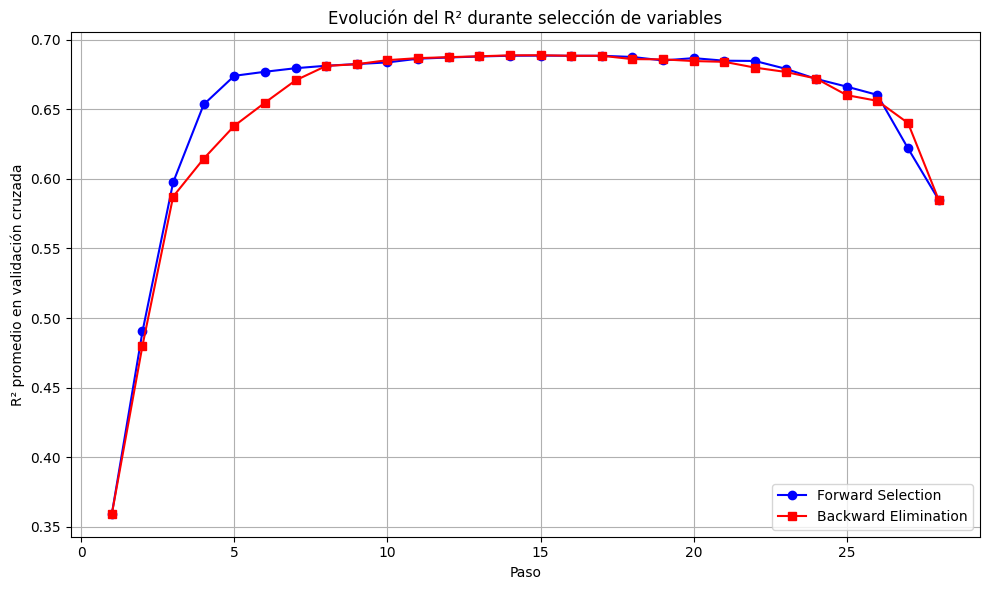

In [ ]:
# Crear listas con el número de variables y el R² en cada paso
steps_forward = list(history_forward.keys())
r2_forward = [info['avg_score'] for info in history_forward.values()]

steps_backward = list(history_backward.keys())
r2_backward = [info['avg_score'] for info in history_backward.values()]

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(steps_forward, r2_forward, marker='o', label='Forward Selection', color='blue')
plt.plot(steps_backward, r2_backward, marker='s', label='Backward Elimination', color='red')

plt.xlabel('Paso')
plt.ylabel('R² promedio en validación cruzada')
plt.title('Evolución del R² durante selección de variables')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

| Aspecto                         | Explicación clara                                                                                                                                                                                                              |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Qué se calcula en cada paso** | R² promedio en validación cruzada (CV) dentro de `X_train`. Cada paso prueba añadir una variable distinta y evalúa el modelo con `cv=5`.                                                                                       |
| **Por qué no siempre sube**     | Las primeras variables tienen mayor poder predictivo → suben el R² en CV. Después, las variables que quedan tienen menor valor explicativo o están correlacionadas, y pueden hacer que el modelo sobreajuste.                  |
| **R² en train vs R² en CV**     | R² en train siempre sube o se mantiene al añadir variables (porque siempre se ajusta mejor a los datos vistos). R² en CV puede bajar si el modelo deja de generalizar bien.                                                    |
| **Qué refleja el descenso**     | Que añadir más variables ya no ayuda a mejorar el desempeño sobre datos no vistos (en validación cruzada). El modelo empieza a capturar ruido en lugar de señal útil.                                                          |
| **El algoritmo qué garantiza**  | En cada paso añade la mejor candidata que queda (la que menos empeora o más mejora el R² promedio en CV). No garantiza que el nuevo R² promedio supere al anterior, solo que es el mejor posible entre las opciones restantes. |
| **Cómo elegir el mejor modelo** | Observa la evolución del R² promedio en CV (gráfico). Quédate con el paso donde se alcanza el mayor R² promedio, aunque no sea el último paso del forward selection.                                                           |
| **Validación final**            | Después de elegir las variables, ajustas el modelo final sobre `X_train` completo y evalúas en `X_test` para ver el desempeño real en datos completamente nuevos.                                                              |


###Elección del paso con mejor desempeño

In [ ]:
# Buscar el paso con mayor R² promedio
best_step = max(history_forward.items(), key=lambda x: x[1]['avg_score'])
best_variables = list(best_step[1]['feature_names'])
best_r2_cv = best_step[1]['avg_score']

print(f"Mejor paso: {best_step[0]}")
print(f"Variables seleccionadas: {best_variables}")
print(f"R² promedio en CV en train: {best_r2_cv:.4f}")

Mejor paso: 15
Variables seleccionadas: ['precio_bolsa', 't2m', 'rh2m', 'prectotcorr', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
R² promedio en CV en train: 0.6885


### Entrenamiento del modelo con variables más representativas

In [ ]:
lr = LinearRegression()
lr.fit(X_train[best_variables], y_train)

LinearRegression()

### Validación del modelo en el conjunto de evaluación (Test)

In [ ]:
# Predicción en el conjunto de test
y_pred_model_lr = lr.predict(X_test[best_variables])
y_pred_model_lr = pd.Series(lr.predict(X_test[best_variables]),index=y_test.index, name='y_pred_lr')

###**Paso 9.5: Cálculo de las métricas de Evaluación**


In [ ]:
metrics = compute_regression_metrics(y_test, y_pred_model_lr, 'Linear Regression')

********Métricas Linear Regression*********
*
MAE  (Error absoluto medio):            22.19
MSE  (Error cuadrático medio):          776
RMSE (Raíz del error cuadrático medio): 27.86
MAPE (Error porcentual absoluto medio): 7.57%
R²   (Coeficiente de determinación):    0.50


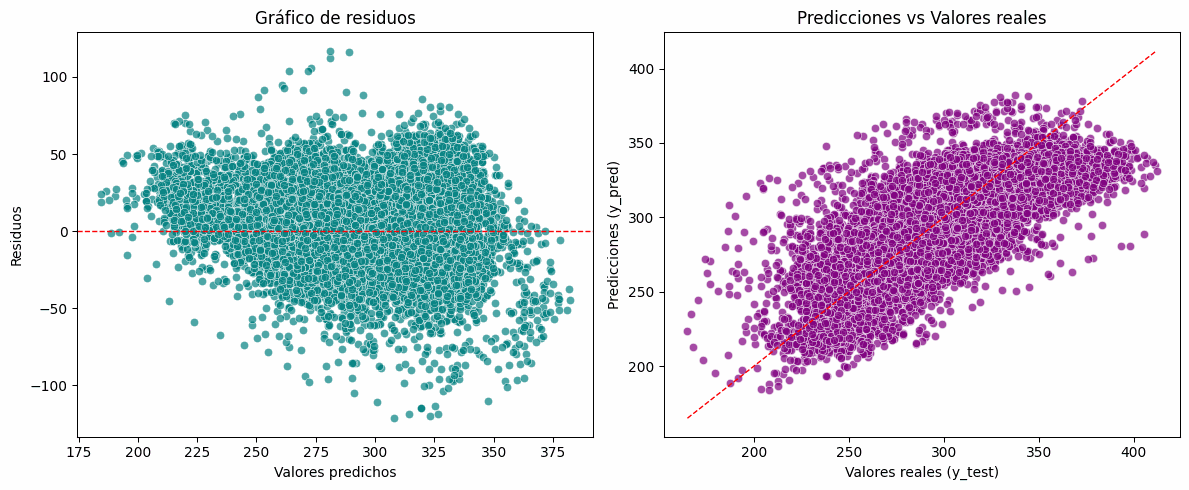

In [ ]:
# --- Visualización de residuos ---
residuos = y_test - y_pred_model_lr

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_pred_model_lr, y=residuos, color='teal', alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Gráfico de residuos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

# --- Gráfico de valores predichos vs reales ---
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_pred_model_lr, color='purple', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=1)
plt.title("Predicciones vs Valores reales")
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_pred)")

plt.tight_layout()
plt.show()

In [ ]:
y_pred_model_lr= pd.DataFrame(y_pred_model_lr,columns=['y_pred_lr'],index=y_test.index)
y_train= pd.DataFrame(y_train,columns=['demanda_real'],index=y_train.index)
y_test= pd.DataFrame(y_test,columns=['demanda_real'],index=y_test.index)

###**Paso 10.5: Visualización de la serie (segmentos de entrenamiento y prueba)**

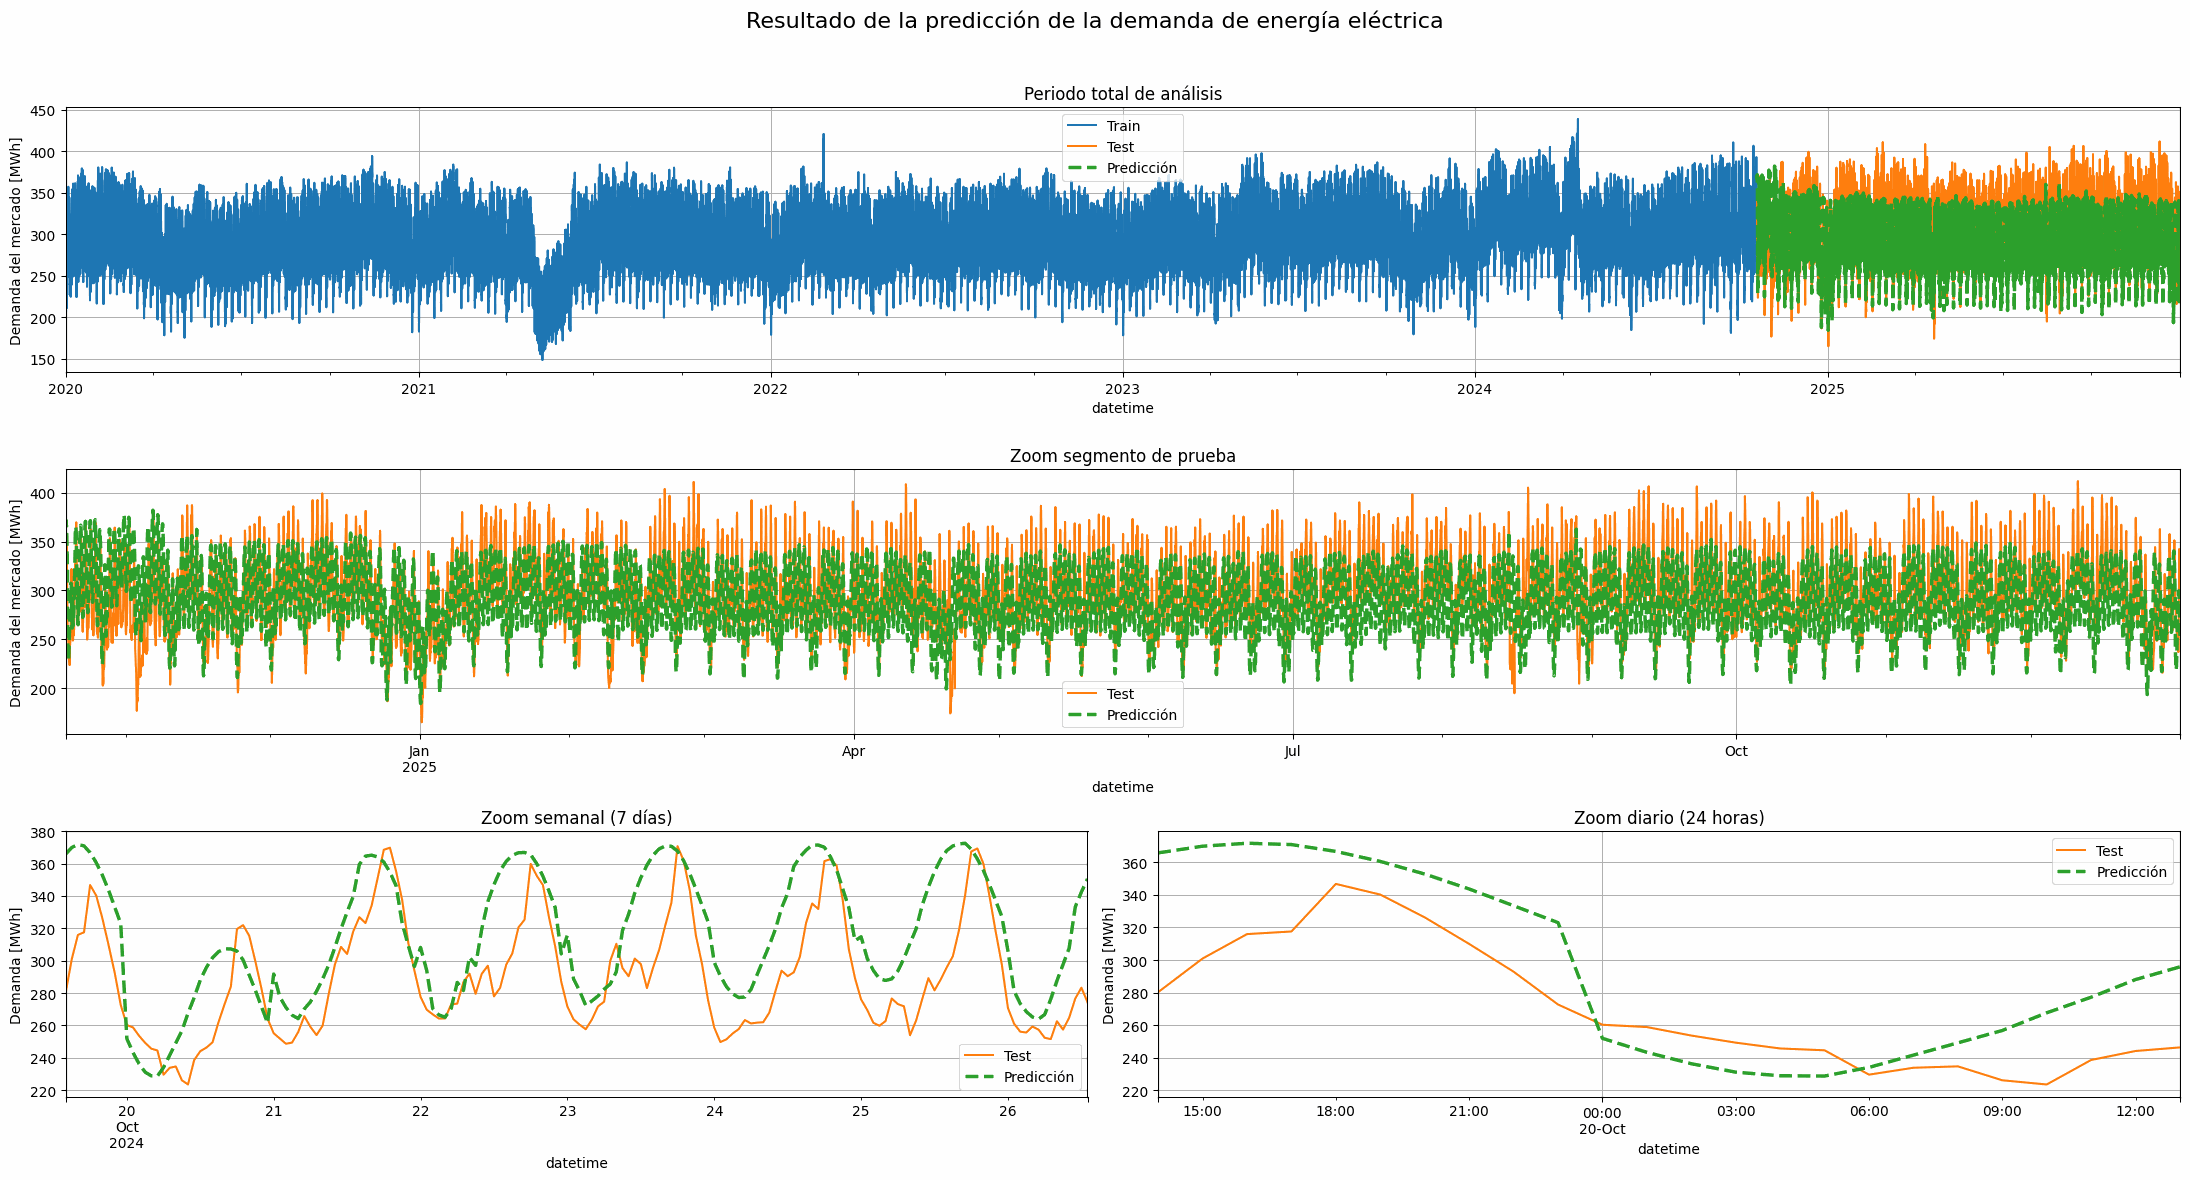

In [ ]:
regresion_graphs(y_train, y_test,y_pred_model_lr['y_pred_lr'])

## **Model Linear Regression con escalamiento**

###Forward selection y Backward Elimination

In [ ]:
lr = LinearRegression()

In [ ]:
# Forward selection
sfs_forward = SFS(lr,
                  k_features='best',
                  forward=True,
                  floating=False,
                  scoring='r2',
                  cv=5,
                  n_jobs=-1)

sfs_forward = sfs_forward.fit(X_train_scaled, y_train_scaled)

# Acceder al historial
history_forward = sfs_forward.get_metric_dict()

print("\n Forward selection paso a paso:")
for step, info in history_forward.items():
    variables = list(info['feature_names'])
    r2 = info['avg_score']
    print(f"Paso {step}: Variables seleccionadas: {variables}, R² promedio en CV: {r2:.4f}")


 Forward selection paso a paso:
Paso 1: Variables seleccionadas: ['hour_sin'], R² promedio en CV: 0.3594
Paso 2: Variables seleccionadas: ['cluster_1', 'hour_sin'], R² promedio en CV: 0.4904
Paso 3: Variables seleccionadas: ['cluster_1', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.5974
Paso 4: Variables seleccionadas: ['cluster_1', 'cluster_7', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6534
Paso 5: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_7', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6740
Paso 6: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_5', 'cluster_7', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6769
Paso 7: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_5', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6795
Paso 8: Variables seleccionadas: ['precio_bolsa', 'cluster_1', 'cluster_3', 'cluster_5', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos'], R² promedio en CV: 0.6812
Paso 9: Varia

In [ ]:
# Backward elimination
sfs_backward = SFS(lr,
                   k_features='best',
                   forward=False,
                   floating=False,
                   scoring='r2',
                   cv=5,
                   n_jobs=-1)

sfs_backward = sfs_backward.fit(X_train_scaled, y_train_scaled)

# Acceder al historial
history_backward = sfs_backward.get_metric_dict()

print("\n Backward elimination paso a paso:")
for step, info in history_backward.items():
    variables = list(info['feature_names'])
    r2 = info['avg_score']
    print(f"Paso {step}: Variables seleccionadas: {variables}, R² promedio en CV: {r2:.4f}")


 Backward elimination paso a paso:
Paso 28: Variables seleccionadas: ['trm', 'ipp', 'ipc', 'no_residencial', 'residencial', 'precio_bolsa', 'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m', 'rh2m', 'prectotcorr', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos'], R² promedio en CV: 0.5850
Paso 27: Variables seleccionadas: ['trm', 'ipc', 'no_residencial', 'residencial', 'precio_bolsa', 'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m', 'rh2m', 'prectotcorr', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos'], R² promedio en CV: 0.6401
Paso 26: Variables seleccionadas: ['trm', 'ipc', 'no_residencial', 'precio_bolsa', 'capacidad_solar', 'capacidad_termica', 'allsky', 'clrsky', 't2m', 'rh2m',

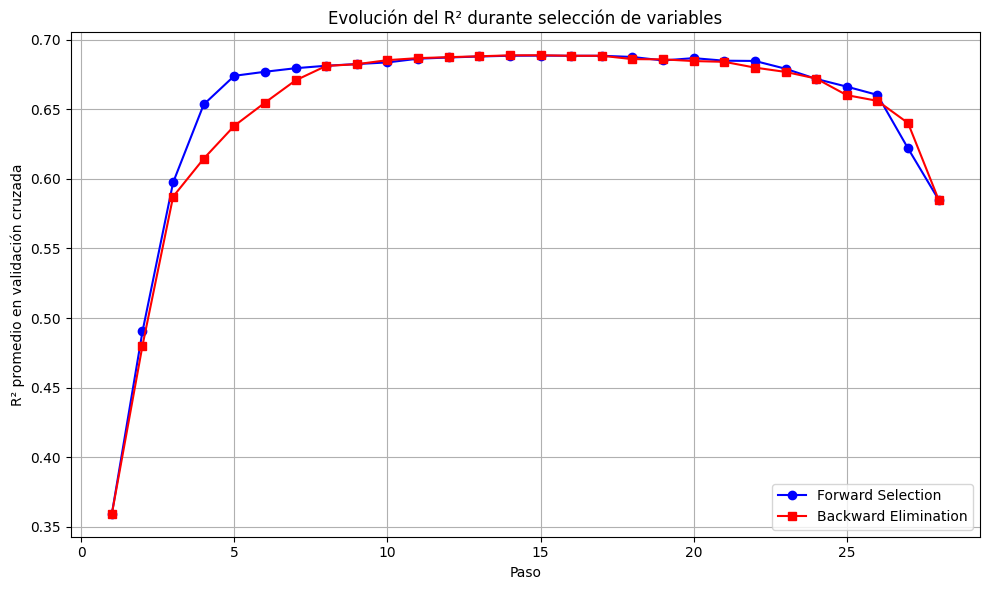

In [ ]:
# Crear listas con el número de variables y el R² en cada paso
steps_forward = list(history_forward.keys())
r2_forward = [info['avg_score'] for info in history_forward.values()]

steps_backward = list(history_backward.keys())
r2_backward = [info['avg_score'] for info in history_backward.values()]

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(steps_forward, r2_forward, marker='o', label='Forward Selection', color='blue')
plt.plot(steps_backward, r2_backward, marker='s', label='Backward Elimination', color='red')

plt.xlabel('Paso')
plt.ylabel('R² promedio en validación cruzada')
plt.title('Evolución del R² durante selección de variables')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Buscar el paso con mayor R² promedio
best_step = max(history_forward.items(), key=lambda x: x[1]['avg_score'])
best_variables_scaled = list(best_step[1]['feature_names'])
best_r2_cv = best_step[1]['avg_score']

print(f"Mejor paso: {best_step[0]}")
print(f"Variables seleccionadas: {best_variables_scaled}")
print(f"R² promedio en CV en train: {best_r2_cv:.4f}")

Mejor paso: 15
Variables seleccionadas: ['precio_bolsa', 't2m', 'rh2m', 'prectotcorr', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
R² promedio en CV en train: 0.6885


### Entrenamiento del modelo con variables más representativas

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled[best_variables_scaled], y_train_scaled)

LinearRegression()

In [ ]:
# Predicción en el conjunto de test
y_pred_model_lr_scaled = lr.predict(X_test_scaled[best_variables_scaled])
y_pred_model_lr_scaled = pd.Series(lr.predict(X_test_scaled[best_variables_scaled]),index=y_test_scaled.index, name='y_pred_lr')

In [ ]:
# Predicción con variable "demanda_real" escalada con y_scaler
y_pred_array = np.asarray(y_pred_model_lr_scaled)

# Invertir escalado
y_pred_model_lr_new = scaler_y.inverse_transform(y_pred_array.reshape(-1, 1)).flatten()

# Reconstruir como DataFrame usando índice de y_test
y_pred_model_lr_new = pd.DataFrame(y_pred_model_lr_new,columns=['y_pred_lr'],index=y_test.index)


In [ ]:
# # Predicción con variable "demanda_real" escalada con y_scaler
# y_pred_array = np.asarray(y_pred_scaled)

# # Invertir escalado
# y_pred = scaler_y.inverse_transform(y_pred_array.reshape(-1, 1)).flatten()

# # Reconstruir como DataFrame usando índice de y_test
# y_pred= pd.DataFrame(y_pred,columns=['y_pred'],index=y_test.index)

In [ ]:
y_pred_model_lr_new= pd.DataFrame(y_pred_model_lr_new,columns=['y_pred_lr'],index=y_test.index)
y_train= pd.DataFrame(y_train,columns=['demanda_real'],index=y_train.index)
y_test= pd.DataFrame(y_test,columns=['demanda_real'],index=y_test.index)

###**Paso 9.6: Cálculo de las métricas de Evaluación**

In [ ]:
metrics = compute_regression_metrics(y_test, y_pred_model_lr_new, 'Linear Regression scaled')

********Métricas Linear Regression scaled*********
*
MAE  (Error absoluto medio):            22.19
MSE  (Error cuadrático medio):          776
RMSE (Raíz del error cuadrático medio): 27.86
MAPE (Error porcentual absoluto medio): 7.57%
R²   (Coeficiente de determinación):    0.50


###**Paso 10.6: Visualización de la serie (segmentos de entrenamiento y prueba)**

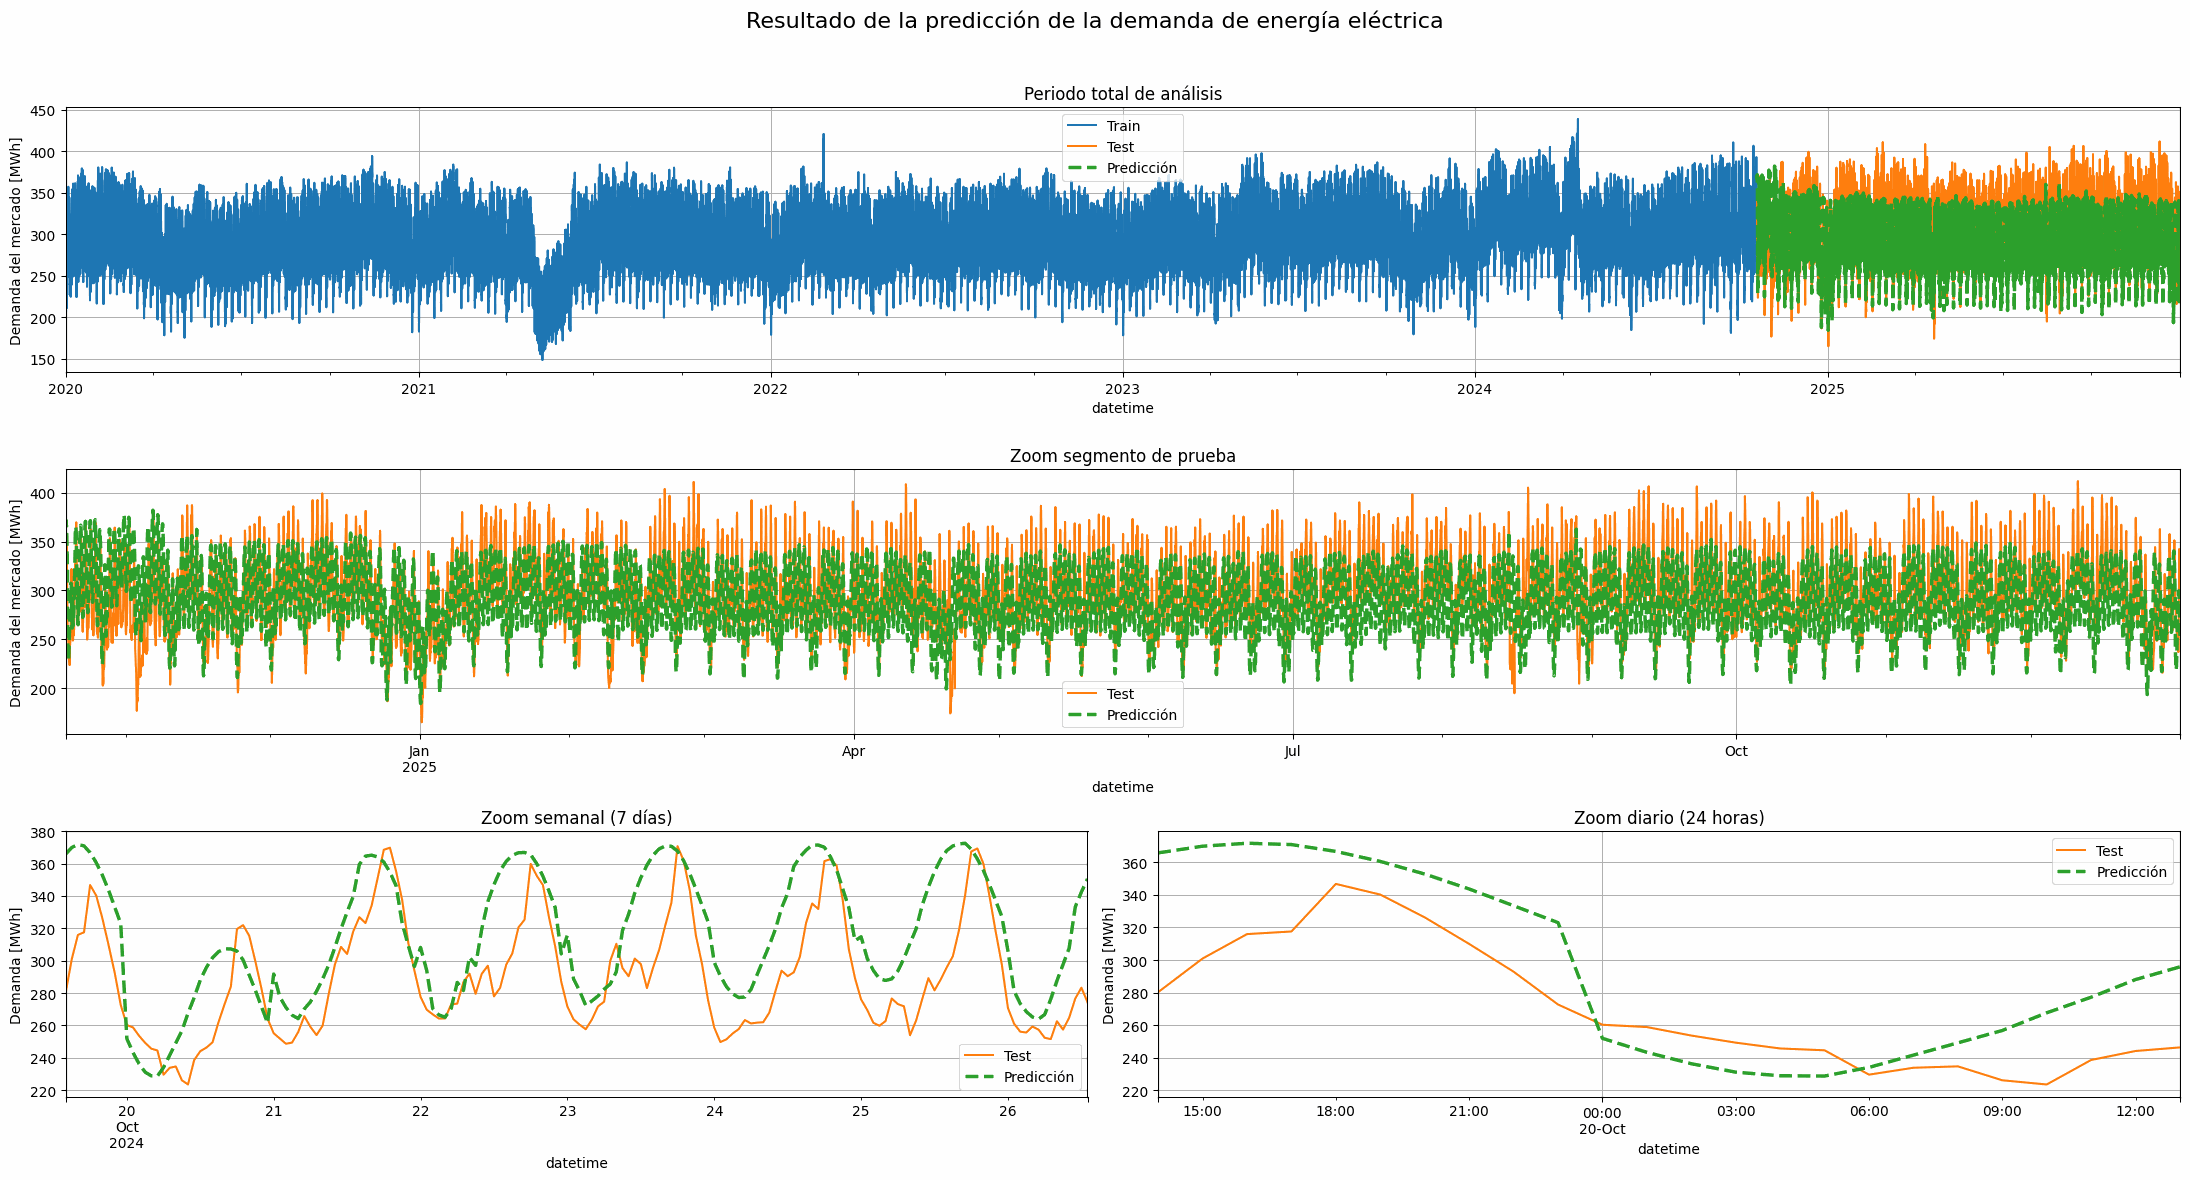

In [ ]:
regresion_graphs(y_train, y_test,y_pred_model_lr_new['y_pred_lr'])

## **Model Support Vector Regressor**

### Selección de las mejores características

In [ ]:
# Selección de las mejores características
dtr = DecisionTreeRegressor()

dtr.fit(X_train_scaled, y_train_scaled)

# % de importancia
importance = dtr.feature_importances_
data_importance = pd.DataFrame({'feature': X_train_scaled.columns, 'importance': importance})
data_importance = data_importance.sort_values(by='importance', ascending=False)

data_importance

,feature,importance
22,hour_sin,0.338771
10,t2m,0.208682
14,cluster_1,0.094849
13,cluster_0,0.068187
5,precio_bolsa,0.035573
20,cluster_7,0.032476
6,capacidad_solar,0.024815
23,hour_cos,0.023248
27,doy_cos,0.022431
26,doy_sin,0.021678


### Predicción con todas las caracteristicas

## **Model Support Vector Machine (SVR)**

In [ ]:
svr = SVR()
# Se genera el entrenamiento
svr.fit(X_train_scaled, y_train_scaled)

SVR()

In [ ]:
# Se genera la predicción
prediction_scaled = svr.predict(X_test_scaled)

In [ ]:
prediction_scaled = pd.DataFrame(prediction_scaled,columns=['y_pred_svr'],index=y_test.index)

In [ ]:
y_pred = inverse_scale_y (prediction_scaled, scaler_y,y_test.index, name='y_pred_svr', as_dataframe=True)

###**Paso 9.7: Cálculo de las métricas de Evaluación**

In [ ]:
metrics_7 = compute_regression_metrics(y_test, y_pred, 'Suppor Vector Regressor')

********Métricas Suppor Vector Regressor*********
*
MAE  (Error absoluto medio):            24.23
MSE  (Error cuadrático medio):          940
RMSE (Raíz del error cuadrático medio): 30.66
MAPE (Error porcentual absoluto medio): 8.14%
R²   (Coeficiente de determinación):    0.40


In [ ]:
y_pred= pd.DataFrame(y_pred,columns=['y_pred_svr'],index=y_test.index)
y_train= pd.DataFrame(y_train,columns=['demanda_real'],index=y_train.index)
y_test= pd.DataFrame(y_test,columns=['demanda_real'],index=y_test.index)

###**Paso 10.7: Visualización de la serie (segmentos de entrenamiento y prueba)**

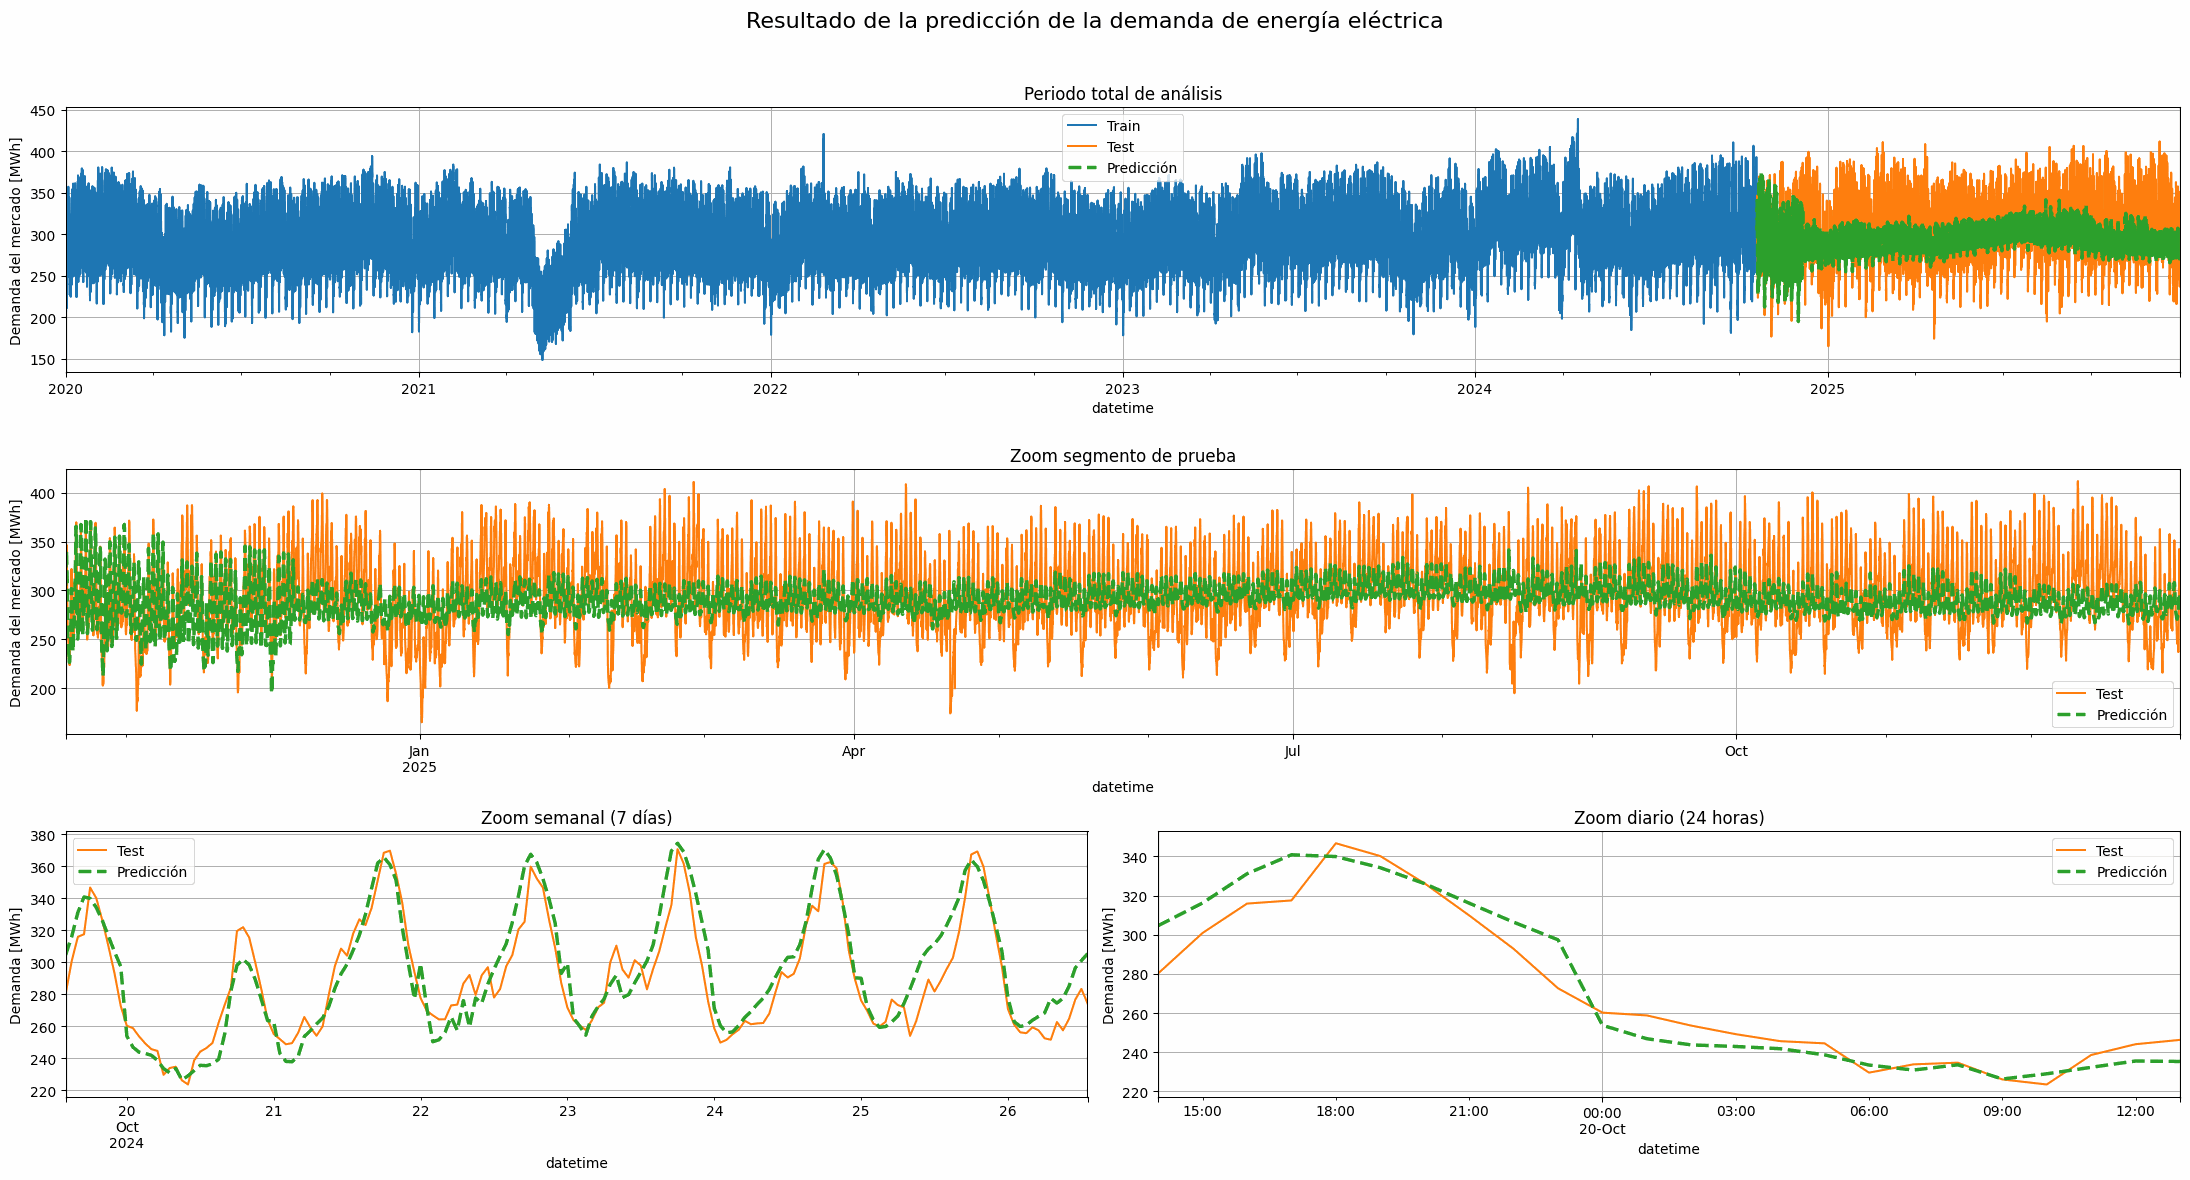

In [ ]:
regresion_graphs(y_train, y_test,y_pred['y_pred_svr'])

## **Model Random Forest Regressor (RFR)**

In [ ]:
rfr = RandomForestRegressor()
# Se genera el entrenamiento
rfr.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
# Se genera la predicción
prediction_rf = rfr.predict(X_test)

In [ ]:
df_prediction_rf = pd.DataFrame(prediction_rf,columns=['y_pred_rf'],index=y_test.index)

###**Paso 9.8: Cálculo de las métricas de Evaluación**

In [ ]:
metrics_8 = compute_regression_metrics(y_test, df_prediction_rf, 'Random Forest Regressor')

********Métricas Random Forest Regressor*********
*
MAE  (Error absoluto medio):            18.14
MSE  (Error cuadrático medio):          514
RMSE (Raíz del error cuadrático medio): 22.67
MAPE (Error porcentual absoluto medio): 6.16%
R²   (Coeficiente de determinación):    0.67


In [ ]:
y_pred= pd.DataFrame(df_prediction_rf,columns=['y_pred_rf'],index=y_test.index)
y_train= pd.DataFrame(y_train,columns=['demanda_real'],index=y_train.index)
y_test= pd.DataFrame(y_test,columns=['demanda_real'],index=y_test.index)

###**Paso 10.8: Visualización de la serie (segmentos de entrenamiento y prueba)**

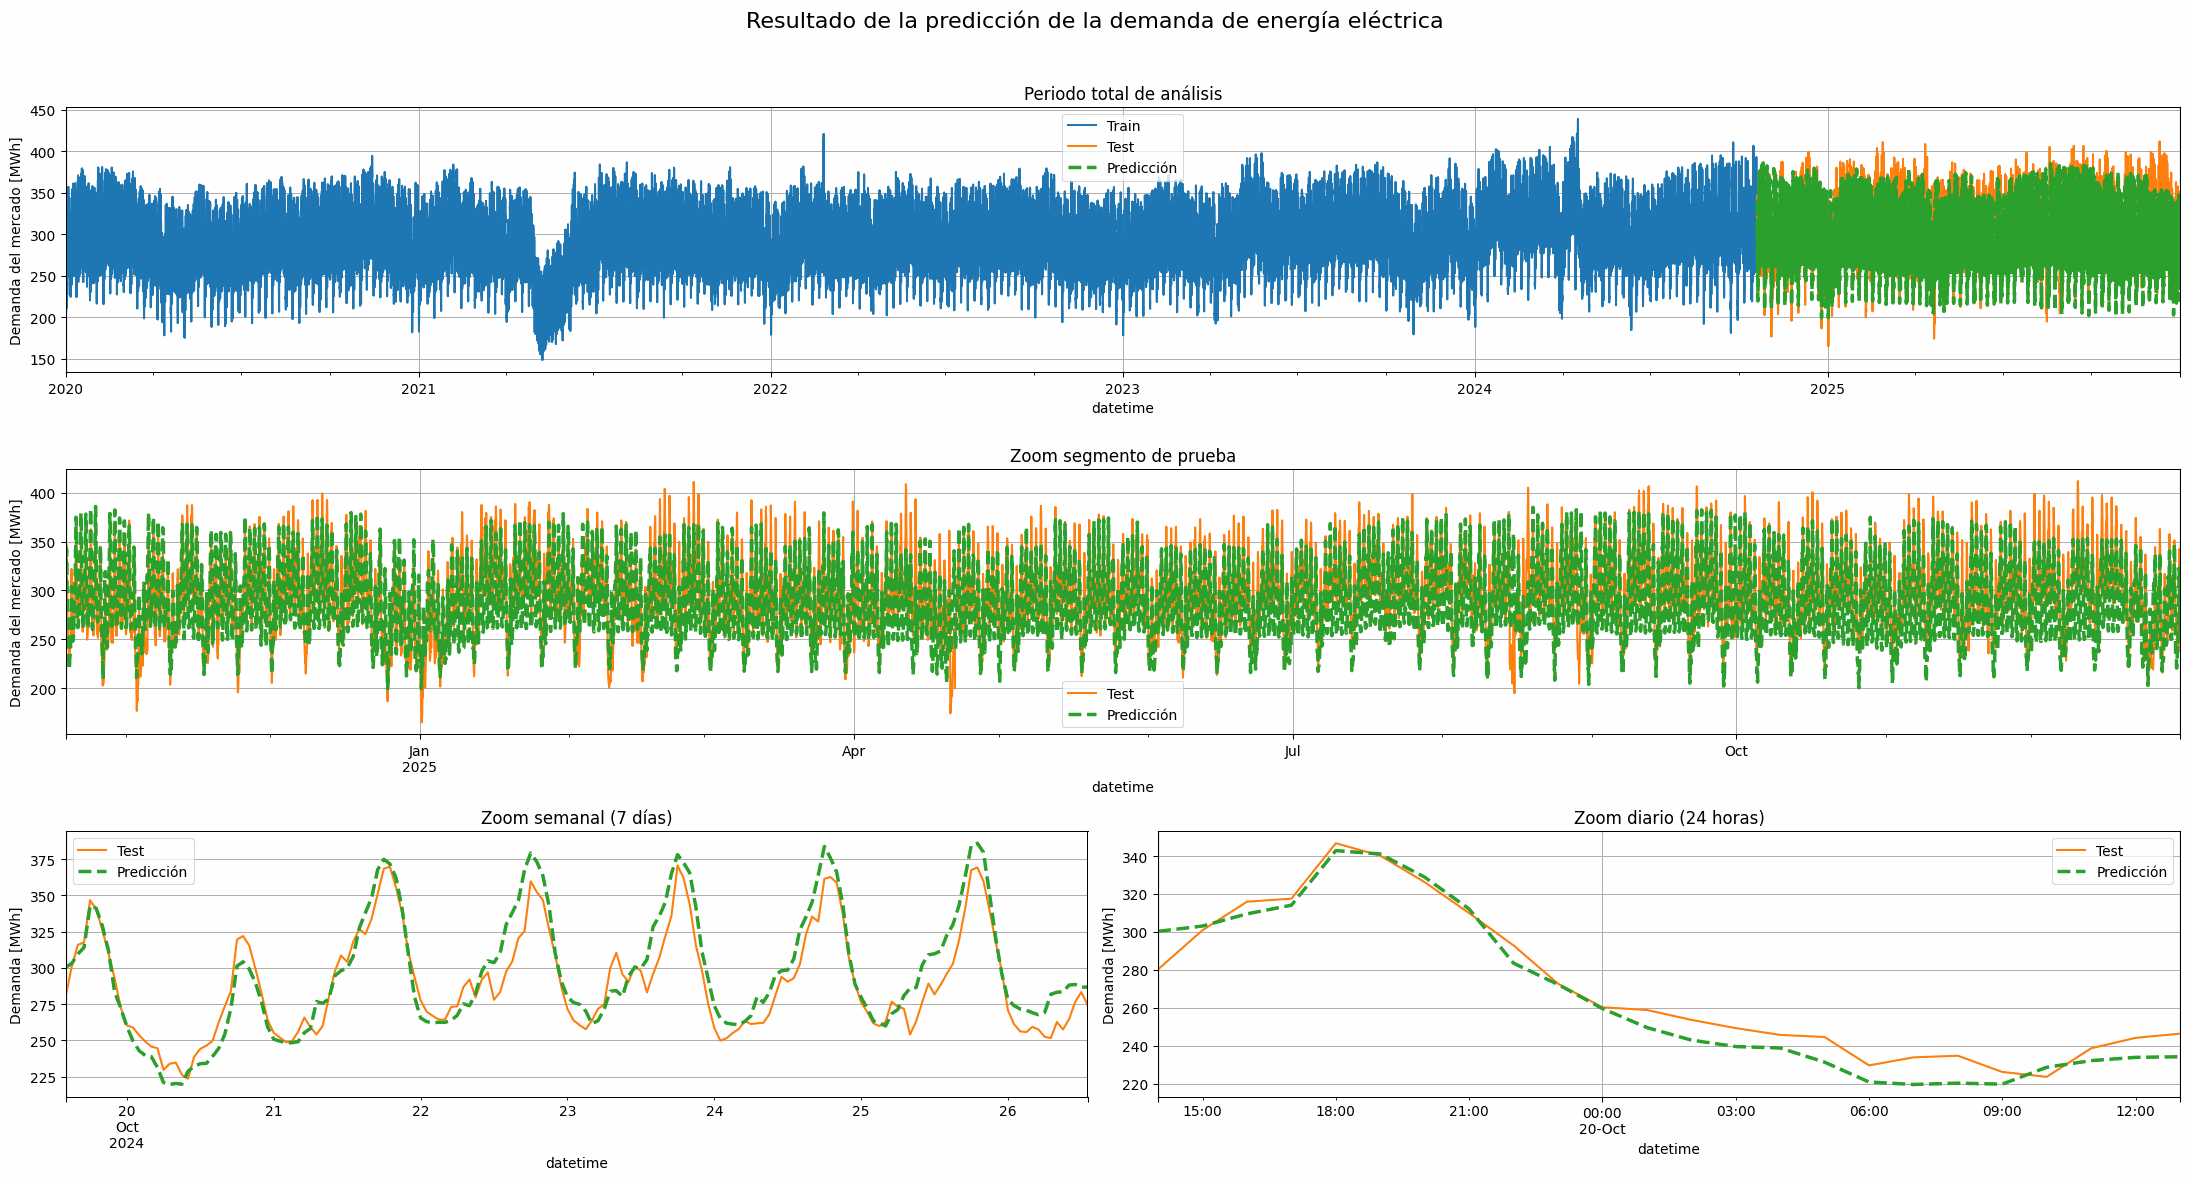

In [ ]:
regresion_graphs(y_train, y_test,df_prediction_rf['y_pred_rf'])

## **Model eXtreme Gradient Boosting (XGBoots)**

In [ ]:
model_xgb = xgb.XGBRegressor()
# Se genera el entrenamiento
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Se genera la predicción
prediction_xgb = model_xgb.predict(X_test)

In [ ]:
df_prediction_xgb = pd.DataFrame(prediction_xgb,columns=['y_pred_xgb'],index=y_test.index)

In [ ]:
metrics_9 = compute_regression_metrics(y_test, df_prediction_xgb, 'Extreme Gradient Boosting')

********Métricas Extreme Gradient Boosting*********
*
MAE  (Error absoluto medio):            19.05
MSE  (Error cuadrático medio):          558
RMSE (Raíz del error cuadrático medio): 23.63
MAPE (Error porcentual absoluto medio): 6.44%
R²   (Coeficiente de determinación):    0.64


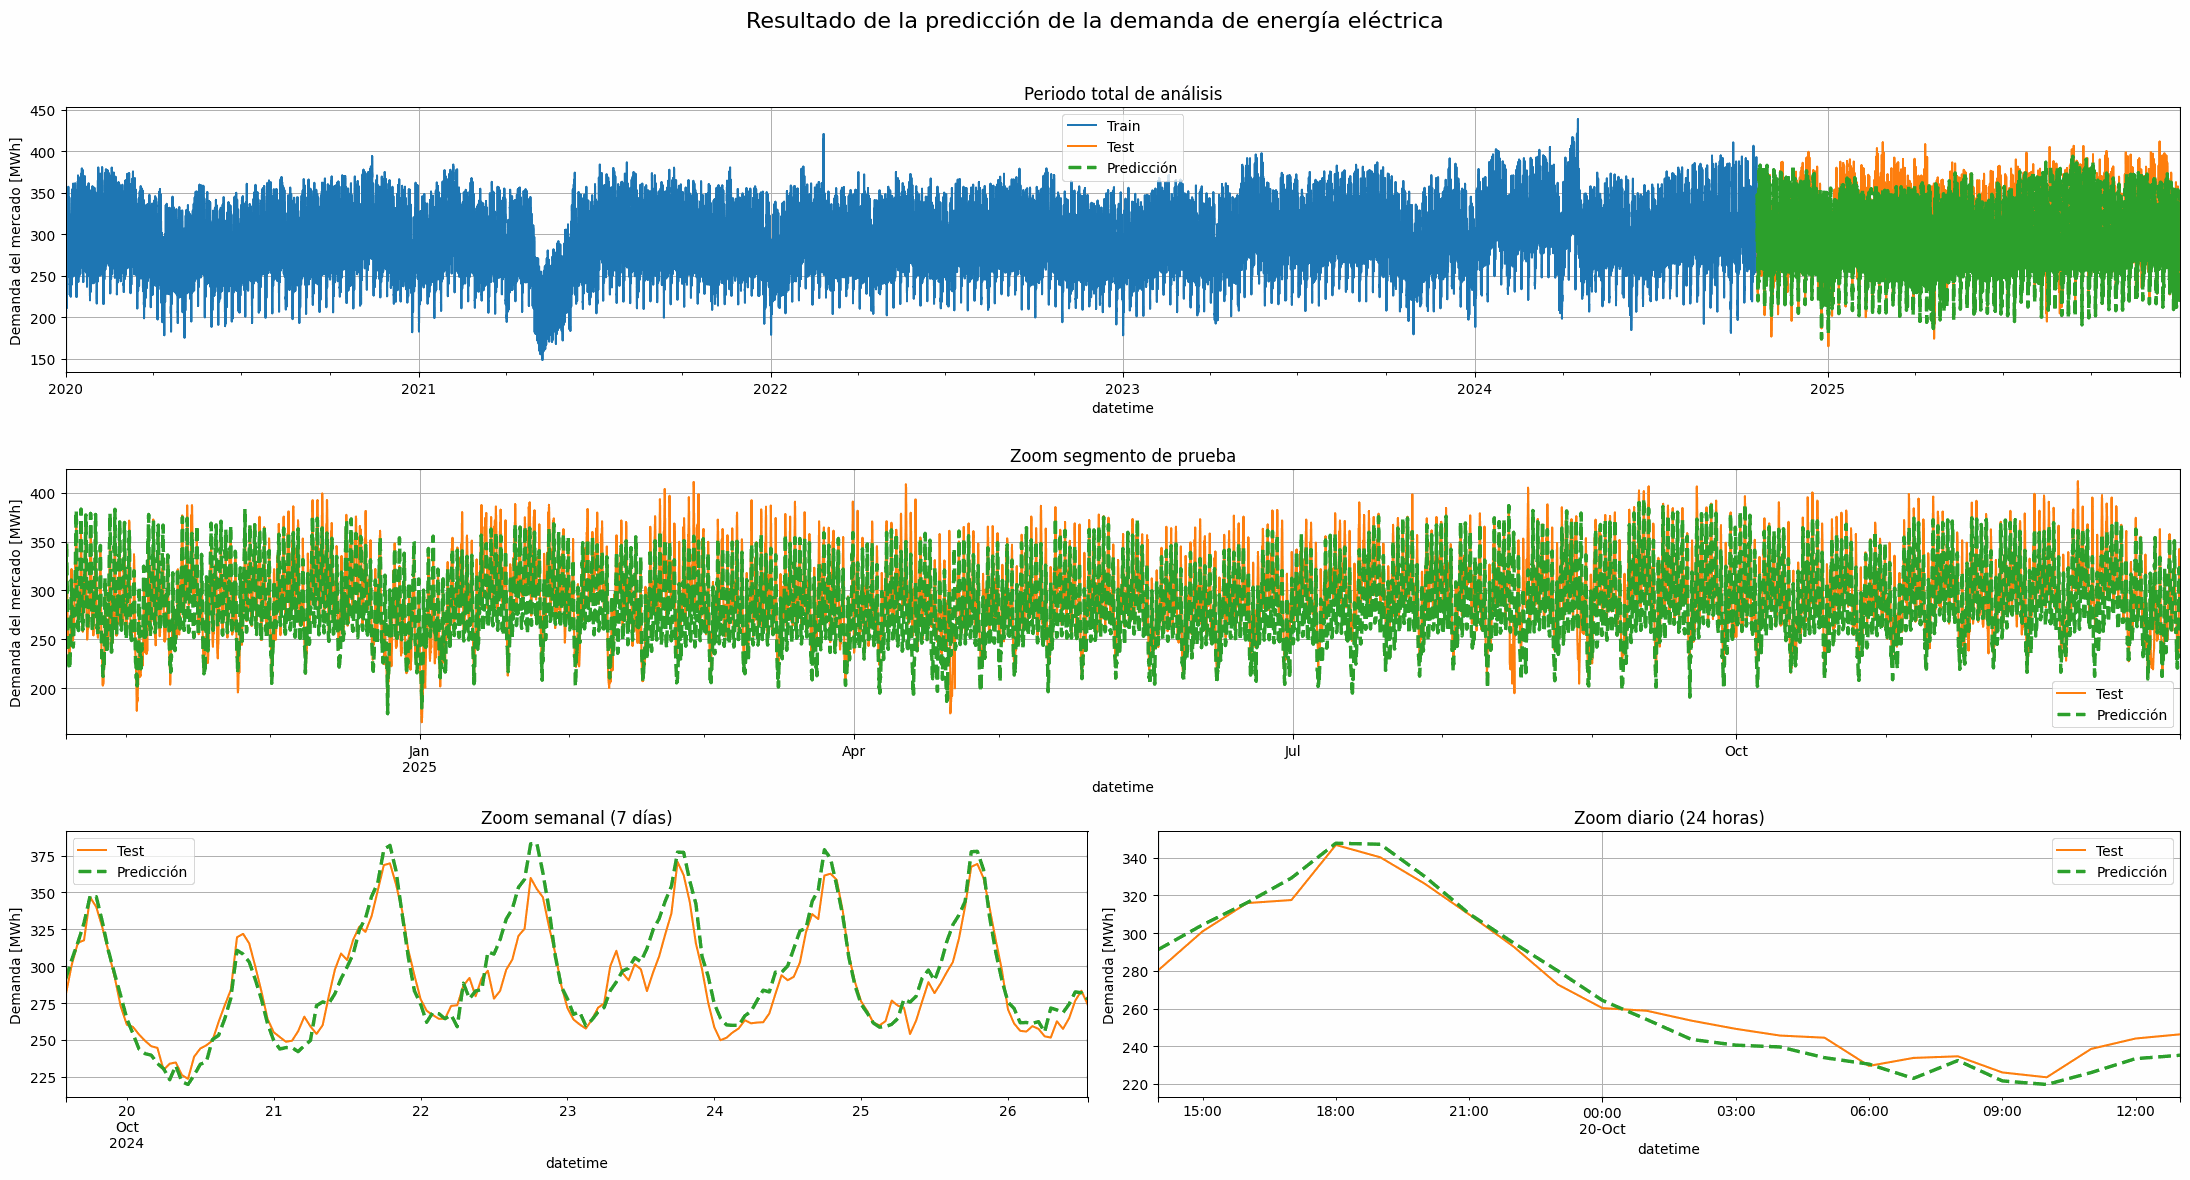

In [ ]:
regresion_graphs(y_train, y_test,df_prediction_xgb['y_pred_xgb'])

## **Model Light Gradient-Boosting Machine (LightGBM)**

In [ ]:
# Create forecaster
# ==============================================================================
model_lgbm = LGBMRegressor()

In [ ]:
# Train forecaster
# ==============================================================================
model_lgbm.fit(X_train, y_train)
model_lgbm

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2836
[LightGBM] [Info] Number of data points in the train set: 42086, number of used features: 28
[LightGBM] [Info] Start training from score 290.520674


LGBMRegressor()

In [ ]:
# Se genera la predicción
prediction_lgbm = model_lgbm.predict(X_test)

In [ ]:
df_prediction_lgbm = pd.DataFrame(prediction_lgbm,columns=['y_pred_lgbm'],index=y_test.index)

In [ ]:
metrics_10 = compute_regression_metrics(y_test, df_prediction_lgbm, 'Light Gradient-Boosting Machine')

********Métricas Light Gradient-Boosting Machine*********
*
MAE  (Error absoluto medio):            17.79
MSE  (Error cuadrático medio):          488
RMSE (Raíz del error cuadrático medio): 22.10
MAPE (Error porcentual absoluto medio): 6.00%
R²   (Coeficiente de determinación):    0.69


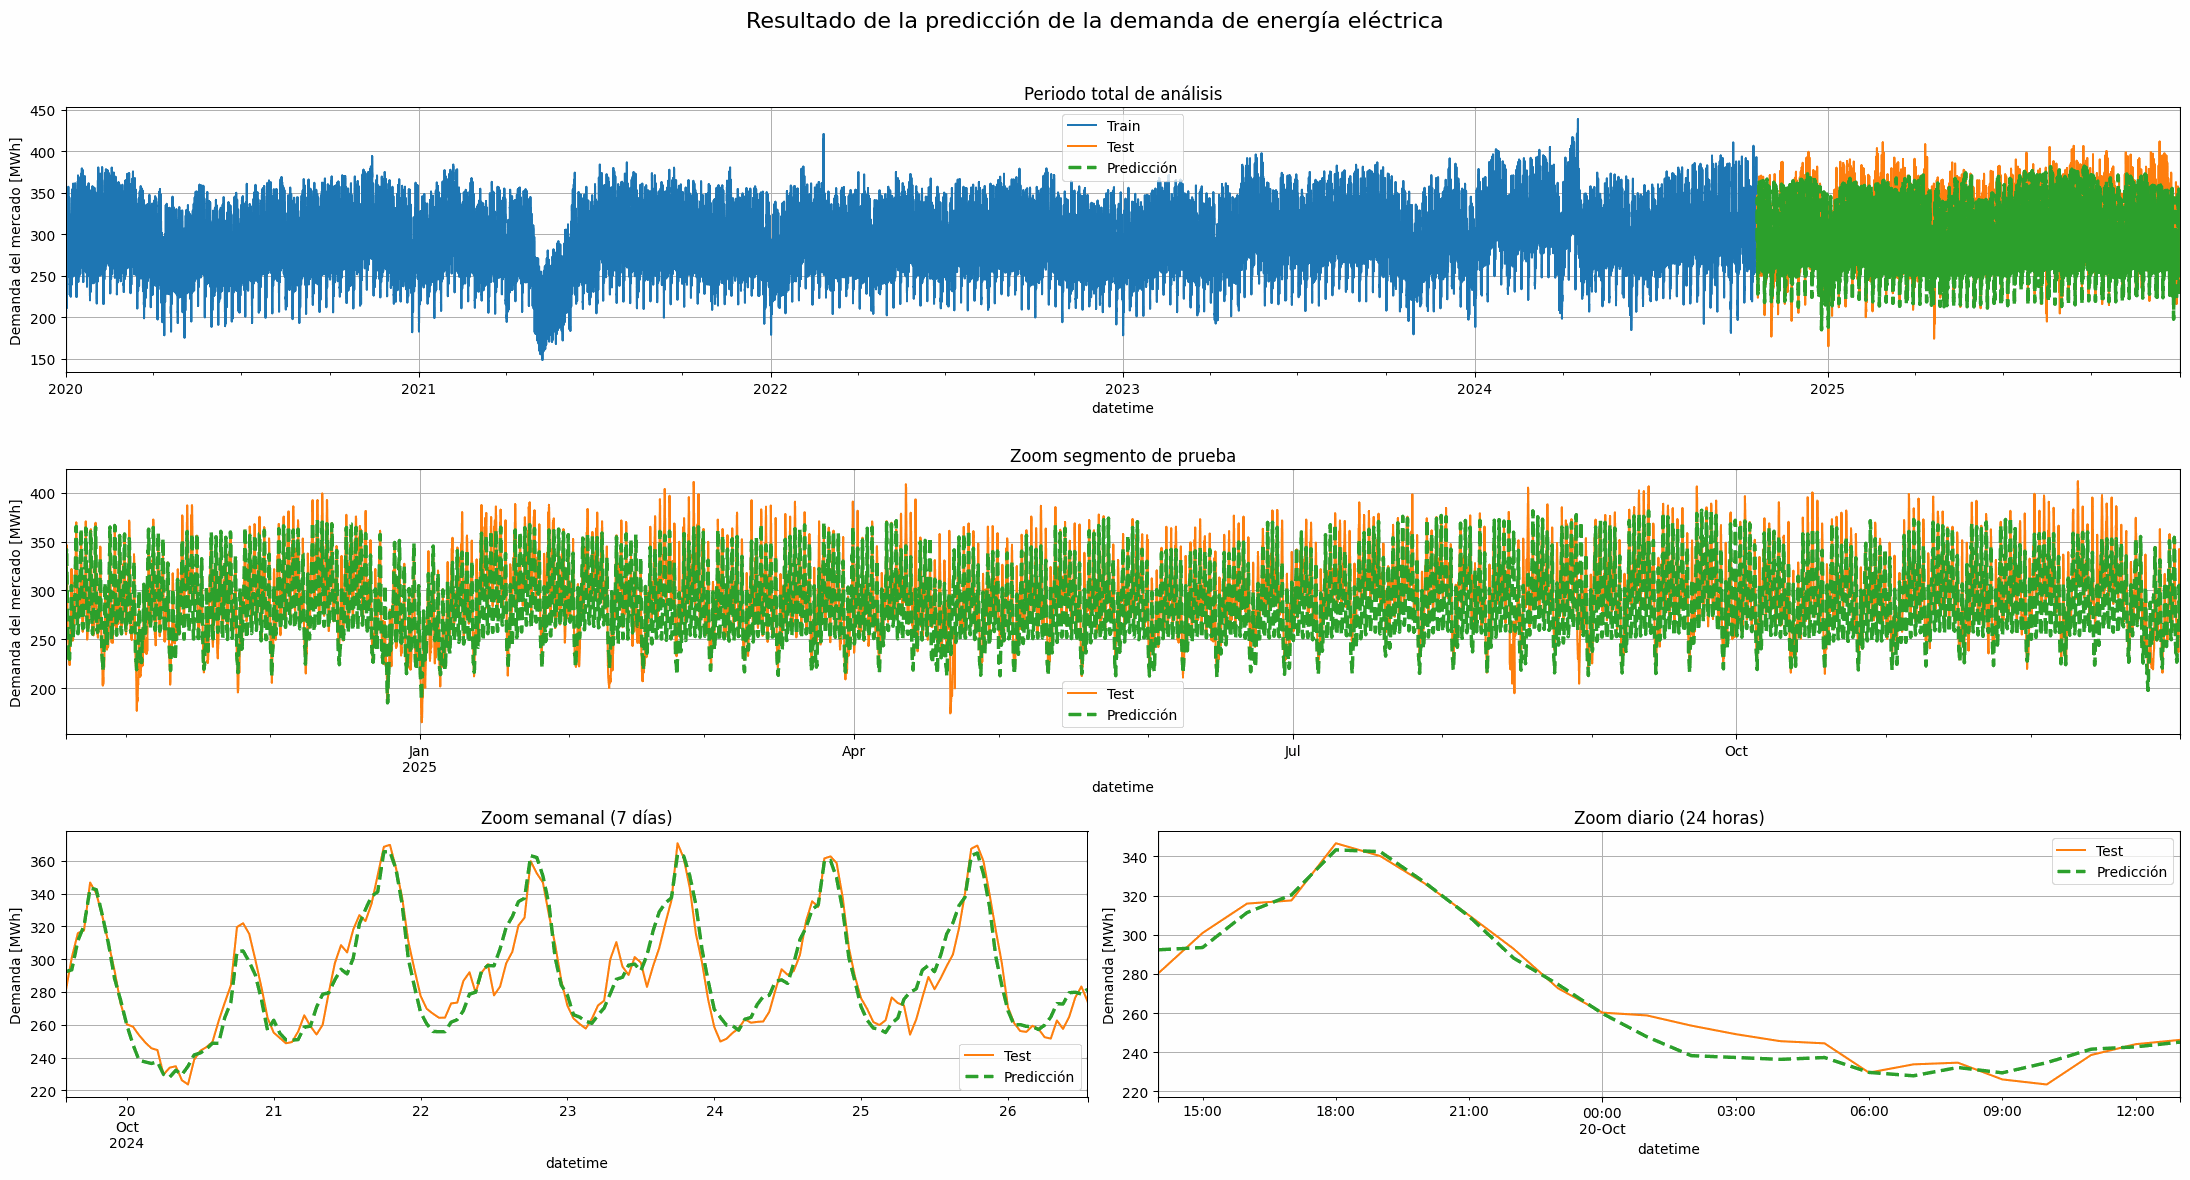

In [ ]:
regresion_graphs(y_train, y_test,df_prediction_lgbm['y_pred_lgbm'])